# Project Introduction [complexity]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **complexity classification of text**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup & Reproducibility](#section-0-environment-setup-reproducibility)
- [SECTION 1 — Utility Functions & Helper Classes](#section-1-utility-functions-helper-classes)
  - [1.1 Core Constants, Reproducibility & Plot Display](#section-1-1-core-constants-reproducibility-plot-display)
  - [1.2 Text Preprocessing Helpers](#section-1-2-text-preprocessing-helpers)
  - [1.3 EDA Text Feature Helpers](#section-1-3-eda-text-feature-helpers)
  - [1.4 Evaluation, I/O, Splitting, and Model Utilities](#section-1-4-evaluation-io-splitting-and-model-utilities)
  - [1.5 Embedding & Sequence Utilities](#section-1-5-embedding-sequence-utilities)
  - [1.6 Neural Architecture Utilities](#section-1-6-neural-architecture-utilities)
  - [1.7 Training Utilities (Shared Deep Learning Loop)](#section-1-7-training-utilities-shared-deep-learning-loop)
  - [1.8 Deep Experiment Runner Utilities](#section-1-8-deep-experiment-runner-utilities)
  - [1.9 Transformer Utilities](#section-1-9-transformer-utilities)
  - [1.10 Reporting, Cross-Dataset, Artifact, and Inference Utilities](#section-1-10-reporting-cross-dataset-artifact-and-inference-utilities)
  - [1.11 Utility Registry Summary](#section-1-11-utility-registry-summary)
- [SECTION 2 — Data Loading & Inspection](#section-2-data-loading-inspection)
- [SECTION 3 — Data Preparation](#section-3-data-preparation)
  - [3.1 Preprocessing Steps](#section-3-1-preprocessing-steps)
  - [3.2 Train/Val/Test Split](#section-3-2-train-val-test-split)
- [SECTION 4 — Baseline Models](#section-4-baseline-models)
  - [4.1 Preparation & Architecture](#section-4-1-preparation-architecture)
  - [4.2 Training](#section-4-2-training)
  - [4.3 Results](#section-4-3-results)
- [SECTION 5 — Static Embeddings + Models (FastText, MLP + CNN)](#section-5-static-embeddings-models)
  - [5.1 Preparation & Architecture](#section-5-1-preparation-architecture)
  - [5.2 Training](#section-5-2-training)
  - [5.3 Results](#section-5-3-results)
- [SECTION 6 — Recurrent Models (BiLSTM / BiGRU)](#section-6-recurrent-models-bilstm-bigru)
  - [6.1 Preparation & Architecture](#section-6-1-preparation-architecture)
  - [6.2 Training](#section-6-2-training)
  - [6.3 Results](#section-6-3-results)
- [SECTION 7 — Transformer Fine-Tuning](#section-7-transformer-fine-tuning)
  - [7.1 Preparation & Architecture](#section-7-1-preparation-architecture)
  - [7.2 Training](#section-7-2-training)
    - [7.2.1 Reference DistilBERT](#section-7-2-1-reference-distilbert)
    - [7.2.2 Alternative RoBERTa](#section-7-2-2-alternative-roberta)
    - [7.2.3 Final Transformer](#section-7-2-3-final-transformer)
  - [7.3 Results](#section-7-3-results)
- [SECTION 8 — Cross-Dataset Evaluation](#section-8-cross-dataset-evaluation)
  - [8.1 Held-Out External Corpora](#section-8-cross-dataset-evaluation)
- [SECTION 9 — Model Comparison & Results Table](#section-9-model-comparison-results-table)
- [SECTION 10 — Saving, Logging & Final Report](#section-10-saving-logging-final-report)
  - [10.1 Save Artefacts](#section-10-1-save-artefacts)
  - [10.2 Manual Inference Sanity Check](#section-10-2-manual-inference-sanity-check)
  - [10.3 Final Report](#section-10-3-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - For transformer runs, including cross-dataset evaluation, set `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.
4. **Transformer-focused run**
   - Run Section 7 once preprocessing/splits are available, then iterate primarily on `trf_model`, `batch_size`, `epochs`, and `lr`.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Expected directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. Splits are loaded from `data/complexity_splits.pkl` when preprocessing is skipped.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Checkpoint caching:** Deep and transformer routines reuse existing best checkpoints when found and may skip retraining automatically.
- **Reproducibility:** `set_seed(CFG["seed"])` is applied in Section 1; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.
- **Structure:** Section numbering and anchors below are synchronized with the final notebook layout.


---
<a id="section-0-environment-setup-reproducibility"></a>
# SECTION 0 — Environment Setup & Reproducibility


In [1]:
# ── 0.1 Stdlib ─────────────────────────────────────────
# Stdlib
import json
import logging
import os
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

# Data / viz
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# DB
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK")


Imports OK


In [50]:
# ── 0.2 CFG = { ─────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir": Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir": Path("models/"),
    "log_dir": Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    "task": "complexity-classification",
    "text_col": "text",
    "label_col": "label",
    "num_labels": 3,

    # ── Complexity data protocol
    "encoded_label_col": "label_enc",
    "train_pool_key": "train_pool",
    "train_pool_datasets": ["uk_key_stage", "asap2"],
    "external_eval_dataset_keys": [
        "one_stop",
        "commonlit",
        "cerf",
        "cambridge",
        "asap_aes",
    ],
    "split_artifact_path": Path("data/complexity_splits.pkl"),
    "experiment_dataset_slug": "complexity",

    # ── Notebook execution toggles
    "run_data_prep": False,
    "run_transformer_eval": True,
    "dl_train_mode": True,

    # ── Split
    "test_size": 0.15,
    "val_size": 0.15,

    # ── Cross-validation
    "use_cv": True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams": True,
    "class_weight": "balanced",

    # ── Embeddings
    "embedding_model": "fasttext-wiki-news-subwords-300",
    "embedding_dim": 300,
    "vocab_size": 50_000,
    "max_seq_len": 256,
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs": 20,
    "dl_lr": 1e-3,
    "dl_patience": 3,
    "dropout": 0.3,

    # ── CNN-specific
    "cnn_num_filters": 128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer defaults
    "trf_model": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 8,
    "epochs": 3,
    "lr": 2e-5,

    # ── Device
    "device": (
        "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    ),
}

CFG["output_paths"] = {
    "eda": CFG["output_dir"] / "eda",
    "metrics": CFG["output_dir"] / "metrics",
    "runs": CFG["output_dir"] / "runs",
    "plots_confusion": CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
    "plots_learning": CFG["output_dir"] / "plots" / "learning_curves",
    "plots_history": CFG["output_dir"] / "plots" / "histories",
}

for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)
for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")

Task  : complexity-classification
Labels: 3
Device: mps


---
<a id="section-1-utility-functions-helper-classes"></a>
# SECTION 1 — Utility Functions & Helper Classes

We set up the shared helpers before running the experiments.
We get one consistent toolkit for preprocessing, training, evaluation, and saving artefacts, so the later sections stay aligned.


<a id="section-1-1-core-constants-reproducibility-plot-display"></a>
### 1.1 Core Constants, Reproducibility & Plot Display


In [56]:
# -- 1.1 Core constants, reproducibility, and plot display -----------------
CLASSES = ["A1-A2", "B1-B2", "C1-C2"]
COLORS = ["#003366", "#0066CC", "#4DA6FF", "#99CCFF", "#CCE5FF"]

sns.set_theme(style="whitegrid", palette=COLORS)
plt.rcParams["figure.dpi"] = 120

def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


set_seed(CFG["seed"])
print("Seed set.")

Seed set.


<a id="section-1-2-text-preprocessing-helpers"></a>
### 1.2 Text Preprocessing Helpers


In [57]:
# -- 1.2 Text preprocessing helpers ----------------------------------------
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def normalize_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_from_normalized(text: str, remove_stopwords: bool = True, lemmatize: bool = True) -> str:
    text = text.lower()
    tokens = text.split()
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)

<a id="section-1-3-eda-text-feature-helpers"></a>
### 1.3 EDA Text Feature Helpers


In [58]:
# ── 1.3 from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS ─────────────────────────────────────────
EXTRA_STOPWORDS = globals().get("EXTRA_STOPWORDS", set())
CONSULTING_COLORS = globals().get("CONSULTING_COLORS", COLORS)

def clean_text_fallback(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_top_words_tfidf(df, cls, n=15, label_col=None, text_col="text"):
    if label_col is None:
        for candidate in ["label", "complexity", "age"]:
            if candidate in df.columns:
                label_col = candidate
                break
        else:
            raise ValueError("No label column found. Expected one of: 'label', 'complexity', 'age'.")

    class_texts = {}
    for c in CLASSES:
        texts = (
            df[df[label_col] == c][text_col]
            .dropna()
            .astype(str)
            .apply(clean_text_fallback)
            .tolist()
        )
        class_texts[c] = " ".join(texts)

    all_docs = list(class_texts.values())
    all_labels = list(class_texts.keys())

    vec = TfidfVectorizer(
        stop_words=list(ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)),
        max_features=10_000,
        ngram_range=(1, 1),
        min_df=1,
    )

    X = vec.fit_transform(all_docs)
    words = vec.get_feature_names_out()

    cls_idx = all_labels.index(cls)
    scores = X[cls_idx].toarray().flatten()
    top = sorted(zip(words, scores), key=lambda x: x[1], reverse=True)[:n]

    return pd.DataFrame(top, columns=["word", "score"])

<a id="section-1-4-evaluation-io-splitting-and-model-utilities"></a>
### 1.4 Evaluation, I/O, Splitting, and Model Utilities


In [59]:
# ── 1.4 class DictLabelEncoder: ─────────────────────────────────────────
class DictLabelEncoder:
    def __init__(self, mapping: dict):
        first_key = next(iter(mapping))
        if isinstance(first_key, int):
            id2class = mapping
        else:
            id2class = {v: k for k, v in mapping.items()}
        self.classes_ = np.array([id2class[i] for i in sorted(id2class)])

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=np.int64)
        return np.array([self.classes_[i] if 0 <= i < len(self.classes_) else str(i) for i in y_arr])

    def transform(self, labels):
        class2id = {c: i for i, c in enumerate(self.classes_)}
        labels_arr = np.asarray(labels)
        return np.array([class2id[x] for x in labels_arr], dtype=np.int64)

In [60]:
# ── 1.5 RESULTS = {} ─────────────────────────────────────────
RESULTS = {}

def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")

def now_ts() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")

def size_tag_from_split(split_key: str) -> str:
    m = re.search(r"(\d+[km]?)$", split_key.lower())
    return m.group(1) if m else slugify(split_key)

def first_existing_path(*paths):
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        if pp.exists():
            return pp
    return None

def load_pickle_with_fallback(primary: Path, *fallbacks: Path):
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find pickle file. Tried: {[str(primary), *map(str, fallbacks)]}")
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"Loaded pickle: {path}")
    return obj

def load_csv_with_fallback(primary: Path, *fallbacks: Path) -> pd.DataFrame:
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find CSV file. Tried: {[str(primary), *map(str, fallbacks)]}")
    print(f"Loaded csv: {path}")
    return pd.read_csv(path)

def _link_or_copy_file(src: Path, dst: Path):
    src = Path(src)
    dst = Path(dst)
    if dst.exists() or not src.exists() or not src.is_file():
        return
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except Exception:
        shutil.copy2(src, dst)


def _link_or_copy_dir_contents(src_dir: Path, dst_dir: Path, include_pattern: str = None):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    if not src_dir.exists() or not src_dir.is_dir():
        return False

    dst_dir.mkdir(parents=True, exist_ok=True)
    if include_pattern is None:
        items = [p for p in src_dir.iterdir() if p.name != ".DS_Store"]
    else:
        items = [p for p in src_dir.glob(include_pattern)]

    copied_any = False
    for item in items:
        target = dst_dir / item.name
        if target.exists():
            copied_any = True
            continue
        try:
            if item.is_dir():
                os.symlink(item.resolve(), target, target_is_directory=True)
            else:
                os.symlink(item.resolve(), target)
        except Exception:
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)
        copied_any = True

    return copied_any


def find_latest_experiment_dir(prefix: str, model_root: Path = None, require_best: bool = False):
    model_root = model_root or CFG["model_dir"]
    patt = re.compile(rf"^{re.escape(prefix)}_\d{{8}}_\d{{6}}$")
    candidates = [p for p in model_root.iterdir() if p.is_dir() and patt.match(p.name)]
    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda p: p.name)
    if not require_best:
        return candidates[-1]

    for cand in reversed(candidates):
        best_dir = cand / "best_model"
        if best_dir.exists() and any(best_dir.iterdir()):
            return cand
    return None


def resolve_experiment_paths(model_family: str, dataset: str, size_tag: str, model_root: Path = None) -> dict:
    model_root = model_root or CFG["model_dir"]
    prefix = f"{slugify(model_family)}_{slugify(dataset)}_{slugify(size_tag)}"

    exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=True)
    if exp_root is None:
        exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=False)
    if exp_root is None:
        exp_root = model_root / f"{prefix}_{now_ts()}"

    exp_root.mkdir(parents=True, exist_ok=True)
    paths = {
        "prefix": prefix,
        "root": exp_root,
        "best_model": exp_root / "best_model",
        "checkpoints": exp_root / "checkpoints",
        "runs": exp_root / "runs",
    }
    for key in ["best_model", "checkpoints", "runs"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    return paths


def bootstrap_file_from_legacy(dst_path: Path, legacy_candidates=()):
    dst_path = Path(dst_path)
    if dst_path.exists():
        return dst_path

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_file():
            _link_or_copy_file(p, dst_path)
            if dst_path.exists():
                print(f"Linked/copied legacy file: {p} -> {dst_path}")
                break

    return dst_path


def bootstrap_dir_from_legacy(dst_dir: Path, legacy_candidates=(), include_pattern: str = None):
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if any(dst_dir.iterdir()):
        return dst_dir

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_dir():
            ok = _link_or_copy_dir_contents(p, dst_dir, include_pattern=include_pattern)
            if ok:
                print(f"Bootstrapped legacy dir: {p} -> {dst_dir}")
                break

    return dst_dir


def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (roc_auc_score(y_true, y_prob[:, 1]) if (y_prob is not None and y_prob.shape[1] == 2) else None)

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    if label_encoder is not None:
        class_names = list(label_encoder.classes_)
        labels = np.arange(len(class_names))
        report = classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0)
    else:
        report = classification_report(y_true, y_pred, zero_division=0)

    print()
    print(report)

    metrics = {"accuracy": float(acc), "f1_macro": float(f1_macro), "f1_weighted": float(f1_weight)}
    if auc is not None:
        metrics["roc_auc"] = float(auc)

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    fname = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=f"Confusion Matrix — {model_name}", figsize=(13, 5)):
        print(f"Displayed existing confusion matrix: {fname}")
        return

    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap=globals().get("CMAP", "Blues"),
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def plot_history(history: dict, model_name: str):
    fname = CFG["output_paths"]["plots_history"] / f"history_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=model_name, figsize=(12, 4)):
        print(f"Displayed existing training curve: {fname}")
        return

    if not history or len(history.get("train_loss", [])) == 0:
        print(f"No training history to plot for {model_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o", color=COLORS[0])
    axes[0].plot(history["val_loss"], label="Val", marker="o", color=COLORS[2])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color=COLORS[1])
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def print_results_table():
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<45}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<45}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


def plot_learning_curve_from_metrics(
    metrics,
    figsize=(10, 6),
    title="Learning Curve",
    save_path=None,
    x_log=True,
    force_replot=False,
):
    required_cols = {"model", "split_key", "train_size", "f1_macro"}

    if isinstance(metrics, pd.DataFrame):
        df = metrics.copy()
    else:
        df = pd.DataFrame(metrics)

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for learning curve: {sorted(missing)}")

    df = df.sort_values(["model", "train_size"]).reset_index(drop=True)

    if save_path is not None:
        save_path = Path(save_path)
        if (not force_replot) and display_saved_plot(save_path, title=title, figsize=figsize):
            print(f"Displayed existing learning curve: {save_path}")
            return df

    fig, ax = plt.subplots(figsize=figsize)

    models = df["model"].drop_duplicates().tolist()

    if len(models) <= 5 and "COLORS" in globals() and len(COLORS) >= len(models):
        palette = COLORS[: len(models)]
    else:
        # High-contrast palette so overlapping curves remain distinguishable.
        tableau10 = [
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        ]
        if len(models) <= len(tableau10):
            palette = tableau10[: len(models)]
        else:
            cmap = plt.get_cmap("tab20")
            palette = [cmap(i % cmap.N) for i in range(len(models))]

    color_map = {m: palette[i] for i, m in enumerate(models)}
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    linestyle_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    style_map = {
        m: {
            "marker": marker_cycle[i % len(marker_cycle)],
            "linestyle": linestyle_cycle[i % len(linestyle_cycle)],
        }
        for i, m in enumerate(models)
    }

    majority_name = "Majority Class"

    for model_name in models:
        g = df[df["model"] == model_name]
        color = color_map.get(model_name)
        is_majority = model_name.strip().lower() == majority_name.lower()

        if len(g) == 1:
            if is_majority:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=220,
                    marker="o",
                    color=color,
                    edgecolor="black",
                    linewidth=1.8,
                    label=model_name,
                    zorder=6,
                )
            else:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=95,
                    marker=style_map[model_name]["marker"],
                    color=color,
                    edgecolor="white",
                    linewidth=0.9,
                    label=model_name,
                    zorder=4,
                )
        else:
            ax.plot(
                g["train_size"],
                g["f1_macro"],
                marker=style_map[model_name]["marker"],
                linestyle=style_map[model_name]["linestyle"],
                linewidth=2.4,
                color=color,
                label=model_name,
                zorder=3,
            )

        for _, row in g.iterrows():
            ax.annotate(
                f"{row['split_key']}: {row['f1_macro']:.3f}",
                (row["train_size"], row["f1_macro"]),
                textcoords="offset points",
                xytext=(0, 10 if is_majority else 7),
                ha="center",
                fontsize=9 if is_majority else 8,
                fontweight="bold" if is_majority else "normal",
                color=color,
            )

    if x_log:
        ax.set_xscale("log")
    ax.set_xticks(sorted(df["train_size"].unique().tolist()))
    ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    if majority_name in set(df["model"]):
        y_min = float(df["f1_macro"].min())
        y_max = float(df["f1_macro"].max())
        if y_max > y_min:
            pad = (y_max - y_min) * 0.08
            ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1-macro")
    ax.legend(frameon=True)
    plt.xticks(rotation=25)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return df



def build_baseline_pipeline_models(cfg: dict = None) -> dict:
    cfg = cfg or CFG

    tfidf_kwargs = dict(
        analyzer="word",
        ngram_range=cfg.get("tfidf_word_ngrams", (1, 2)),
        max_features=cfg.get("tfidf_max_features", 100_000),
        sublinear_tf=True,
        min_df=2,
    )

    return {
        "Majority Class": Pipeline([
            ("clf", DummyClassifier(strategy="most_frequent", random_state=cfg["seed"]))
        ]),
        "TF-IDF + LogReg": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LogisticRegression(
                max_iter=1000,
                C=1.0,
                class_weight=cfg.get("class_weight"),
                solver="saga",
                random_state=cfg["seed"],
            )),
        ]),
        "TF-IDF + SVC": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LinearSVC(C=1.0, class_weight=cfg.get("class_weight"), random_state=cfg["seed"]))
        ]),
        "TF-IDF + XGBoost": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="mlogloss",
                random_state=cfg["seed"],
                n_jobs=-1,
                verbosity=0,
            )),
        ]),
    }


def tune_baselines_on_100k(
    models: dict,
    split_100k: dict,
    seed: int = 42,
    n_iter: int = 4,
):
    x_tr, y_tr = split_100k["X_train"], split_100k["y_train"]
    x_va, y_va = split_100k["X_val"], split_100k["y_val"]

    search_spaces = {
        "TF-IDF + LogReg": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0, 4.0],
        },
        "TF-IDF + SVC": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0],
        },
    }

    best_models = {}
    rows = []

    fixed_models = sum(1 for name in models if name in {"Majority Class", "TF-IDF + XGBoost"})
    tuned_models = [name for name in models if name in search_spaces]
    total_steps = fixed_models + len(tuned_models) * n_iter

    with tqdm(total=total_steps, desc="Tuning baselines (reference split)") as pbar:
        for model_name, base_model in models.items():
            if model_name in {"Majority Class", "TF-IDF + XGBoost"}:
                best_models[model_name] = clone(base_model)
                rows.append({
                    "model": model_name,
                    "params": "fixed",
                    "val_f1_macro": np.nan,
                    "selected": True,
                    "note": "kept fixed",
                })
                pbar.set_description(f"{model_name} | fixed")
                pbar.update(1)
                continue

            candidates = list(ParameterSampler(search_spaces[model_name], n_iter=n_iter, random_state=seed))

            best_f1 = -1.0
            best_model = None
            best_params = None

            for params in candidates:
                pbar.set_description(f"{model_name} | tuning")
                est = clone(base_model)
                est.set_params(**params)
                est.fit(x_tr, y_tr)
                preds = est.predict(x_va)
                f1 = f1_score(y_va, preds, average="macro", zero_division=0)

                rows.append({
                    "model": model_name,
                    "params": str(params),
                    "val_f1_macro": f1,
                    "selected": False,
                    "note": "candidate",
                })

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = est
                    best_params = params

                pbar.set_postfix({"best_f1": f"{best_f1:.4f}"})
                pbar.update(1)

            rows.append({
                "model": model_name,
                "params": str(best_params),
                "val_f1_macro": best_f1,
                "selected": True,
                "note": "best_on_reference_val",
            })
            best_models[model_name] = best_model

    tuning_df = pd.DataFrame(rows)
    return best_models, tuning_df


def train_baselines_across_splits(
    models: dict,
    splits: dict,
    split_keys: list,
    label_encoder,
    model_root: Path,
    primary_curve_split: str = "val",
    single_point_models=("Majority Class",),
    single_point_key=None,
):
    if primary_curve_split not in {"val", "test"}:
        raise ValueError("primary_curve_split must be 'val' or 'test'")
    if single_point_key is None and split_keys:
        single_point_key = split_keys[-1]

    model_root.mkdir(parents=True, exist_ok=True)

    curve_rows = []
    eval_rows = []
    model_registry = {}

    total_steps = sum(
        1
        for split_key in split_keys
        for model_name in models
        if not (model_name in set(single_point_models) and split_key != single_point_key)
    )

    with tqdm(total=total_steps, desc="Baseline train/eval") as pbar:
        for split_key in split_keys:
            split = splits[split_key]
            x_tr, y_tr = split["X_train"], split["y_train"]
            x_val, y_val = split["X_val"], split["y_val"]
            x_test, y_test = split["X_test"], split["y_test"]
            train_size = len(x_tr)

            for model_name, base_model in models.items():
                if model_name in set(single_point_models) and split_key != single_point_key:
                    continue

                pbar.set_description(f"{model_name} | {split_key}")

                exp_paths = resolve_experiment_paths(
                    model_family=model_name,
                    dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
                    size_tag=size_tag_from_split(split_key),
                    model_root=model_root,
                )

                legacy_name_old = re.sub(r"[^a-zA-Z0-9_-]+", "_", model_name).strip("_").lower()
                legacy_candidates = [
                    CFG["model_dir"] / "baselines" / f"{legacy_name_old}__{split_key}.pkl",
                    CFG["model_dir"] / "baselines" / f"{slugify(model_name)}__{split_key}.pkl",
                ]
                best_model_file = exp_paths["best_model"] / "model.pkl"
                best_model_file = bootstrap_file_from_legacy(best_model_file, legacy_candidates)

                if best_model_file.exists():
                    est = joblib.load(best_model_file)
                    status = "loaded"
                else:
                    est = clone(base_model)
                    est.fit(x_tr, y_tr)
                    joblib.dump(est, best_model_file)
                    status = "trained"

                tag = f"{model_name} [{split_key}]"

                val_preds = est.predict(x_val)
                test_preds = est.predict(x_test)

                val_metrics = evaluate_clf(tag, y_val, val_preds, label_encoder=label_encoder, split="val")
                test_metrics = evaluate_clf(tag, y_test, test_preds, label_encoder=label_encoder, split="test")

                print(f"Final validation F1 (macro) [{tag}]: {val_metrics['f1_macro']:.4f} ({status})")

                primary_metrics = val_metrics if primary_curve_split == "val" else test_metrics
                curve_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "f1_macro": float(primary_metrics["f1_macro"]),
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "val",
                    "accuracy": float(val_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(val_metrics.get("roc_auc", np.nan)) if "roc_auc" in val_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "test",
                    "accuracy": float(test_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(test_metrics.get("roc_auc", np.nan)) if "roc_auc" in test_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                model_registry[f"{model_name}|{split_key}"] = str(best_model_file)

                pbar.set_postfix({"val_f1": f"{val_metrics['f1_macro']:.4f}"})
                pbar.update(1)

    curve_df = pd.DataFrame(curve_rows).sort_values(["model", "train_size"]).reset_index(drop=True)
    eval_df = pd.DataFrame(eval_rows).sort_values(["model", "split", "train_size"]).reset_index(drop=True)
    return curve_df, eval_df, model_registry


def collect_deep_eval_from_results(
    results: dict,
    splits: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
) -> pd.DataFrame:
    model_alt = "|".join(re.escape(m) for m in models)
    key_pat = re.compile(rf"^({model_alt}) \[(.+?)\] \| {re.escape(split)}$")

    rows = []
    for key, metrics in results.items():
        m = key_pat.match(key)
        if not m:
            continue

        model, split_key = m.groups()
        if split_key not in splits:
            continue

        rows.append({
            "model": model,
            "split_key": split_key,
            "train_size": len(splits[split_key]["X_train"]),
            "split": split,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
            "roc_auc": float(metrics.get("roc_auc", np.nan)) if "roc_auc" in metrics else np.nan,
            "results_key": key,
        })

    if not rows:
        return pd.DataFrame(columns=[
            "model", "split_key", "train_size", "split",
            "accuracy", "f1_macro", "f1_weighted", "roc_auc", "results_key"
        ])

    eval_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model", "split_key", "split"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )
    return eval_df


def build_deep_curve_from_eval(eval_df: pd.DataFrame) -> pd.DataFrame:
    if eval_df.empty:
        return pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])

    return (
        eval_df[["model", "split_key", "train_size", "f1_macro"]]
        .copy()
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )


def render_deep_learning_curves_from_results(
    results: dict,
    splits: dict,
    cfg: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
    title: str = "Deep Model Learning Curves (GloVe MLP/CNN/BiLSTM)",
    save_name: str = "deep_learning_curves_glove.png",
):
    deep_eval_df = collect_deep_eval_from_results(results, splits, models=models, split=split)
    deep_curve_df = build_deep_curve_from_eval(deep_eval_df)

    if deep_curve_df.empty:
        print("No deep model entries found in RESULTS for the requested models/split.")
        return deep_curve_df, deep_eval_df

    for row in deep_curve_df.itertuples(index=False):
        results[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

    display(deep_curve_df)
    display(deep_eval_df)

    plot_learning_curve_from_metrics(
        deep_curve_df,
        title=title,
        save_path=cfg["output_paths"]["plots_learning"] / save_name,
    )

    return deep_curve_df, deep_eval_df

In [61]:
# ── 1.6 def make_splits_and_arrays(df, CFG): ─────────────────────────────────────────
def resolve_target_col(df: pd.DataFrame, cfg: dict | None = None) -> str:
    cfg = cfg or CFG
    candidates = []
    if cfg.get("encoded_label_col"):
        candidates.append(cfg["encoded_label_col"])
    candidates.extend(["label_enc", "age_enc"])

    for col in candidates:
        if col and col in df.columns:
            return col

    raise ValueError(
        f"Missing target column: expected one of {sorted(set(candidates))}."
    )


def prepare_encoded_text_frame(
    df: pd.DataFrame,
    cfg: dict | None = None,
    label_mapping: dict | None = None,
    drop_duplicates: bool = False,
    clean_text: str = "raw",
) -> pd.DataFrame:
    cfg = cfg or CFG
    label_mapping = label_mapping or globals().get("class2id")
    if not label_mapping:
        raise ValueError("label_mapping is required to encode labels.")
    if clean_text == "clean":
        clean_text = "processed"
    if clean_text not in {"raw", "processed"}:
        raise ValueError("clean_text must be 'raw', 'clean', or 'processed'.")

    target_col = cfg.get("encoded_label_col", "label_enc")
    frame = (
        df[[cfg["text_col"], cfg["label_col"]]]
        .dropna(subset=[cfg["text_col"], cfg["label_col"]])
        .copy()
    )
    if drop_duplicates:
        frame = frame.drop_duplicates(subset=[cfg["text_col"]])

    frame = frame[frame[cfg["label_col"]].isin(label_mapping)].reset_index(drop=True)
    frame["text_raw"] = frame[cfg["text_col"]].map(normalize_text)
    if clean_text == "processed":
        frame["text_clean"] = frame["text_raw"].map(preprocess_from_normalized)
    else:
        frame["text_clean"] = frame["text_raw"]
    frame[target_col] = frame[cfg["label_col"]].map(label_mapping).astype(int)
    return frame.reset_index(drop=True)


def make_splits_and_arrays(df, CFG):
    target_col = resolve_target_col(df, CFG)

    df_train_full, df_test = train_test_split(
        df,
        test_size=CFG["test_size"],
        random_state=CFG["seed"],
        stratify=df[target_col],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=CFG["val_size"] / (1 - CFG["test_size"]),
        random_state=CFG["seed"],
        stratify=df_train_full[target_col],
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

    X_train      = df_train["text_clean"].values
    X_val        = df_val["text_clean"].values
    X_test       = df_test["text_clean"].values

    X_train_raw  = df_train["text_raw"].values
    X_val_raw    = df_val["text_raw"].values
    X_test_raw   = df_test["text_raw"].values

    y_train      = df_train[target_col].values
    y_val        = df_val[target_col].values
    y_test       = df_test[target_col].values

    return {
        "df_train": df_train, "df_val": df_val, "df_test": df_test,
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "X_train_raw": X_train_raw, "X_val_raw": X_val_raw, "X_test_raw": X_test_raw,
        "y_train": y_train, "y_val": y_val, "y_test": y_test
    }

cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])

<a id="section-1-5-embedding-sequence-utilities"></a>
### 1.5 Embedding & Sequence Utilities


In [62]:
# ── 1.7 def build_vocab( ─────────────────────────────────────────
def build_vocab(
    texts,
    max_vocab: int = 50_000,
    min_freq: int = 2,
    pad_token: str = "<PAD>",
    unk_token: str = "<UNK>",
) -> dict:
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}

    filtered = [(w, c) for w, c in counter.items() if c >= min_freq]
    filtered.sort(key=lambda x: x[1], reverse=True)

    for word, _ in filtered[: max_vocab - 2]:
        vocab[word] = len(vocab)

    return vocab

In [63]:
# ── 1.8 def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray: ─────────────────────────────────────────
def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix

In [64]:
# ── 1.9 def texts_to_sequences(texts, vocab: dict, max_len: int, ─────────────────────────────────────────
def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs

In [65]:
# ── 1.10 class TextSequenceDataset(Dataset): ─────────────────────────────────────────
class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test

<a id="section-1-6-neural-architecture-utilities"></a>
### 1.6 Neural Architecture Utilities


In [66]:
# -- 1.6 Neural architecture utilities -------------------------------------
def build_embedding_layer(
    embedding_matrix: np.ndarray | None,
    vocab_size: int | None,
    embed_dim: int | None,
    freeze_emb: bool = False,
):
    if embedding_matrix is not None:
        return nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )

    if vocab_size is None or embed_dim is None:
        raise ValueError("vocab_size and embed_dim are required when embedding_matrix is omitted.")

    return nn.Embedding(vocab_size, embed_dim, padding_idx=0)

class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       # (B, L, 1) — zero out PAD
        emb  = self.embedding(x) * mask             # (B, L, D)
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  # masked mean → (B, D)
        return self.fc(doc)

class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, D, L)
        pooled = [
            F.relu(conv(emb)).max(dim=2).values      # (B, F)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  # (B, L)
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        # (B, H)
        return context, weights

class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


<a id="section-1-7-training-utilities-shared-deep-learning-loop"></a>
### 1.7 Training Utilities (Shared Deep Learning Loop)


In [92]:
# ── 1.14 def get_logger(model_name: str) -> logging.Logger: ─────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


# ── 1.6 Single Epoch Helpers ──────────────────────────────────────────────────
def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


def load_torch_checkpoint(model, ckpt_path: Path, device: str):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    return ckpt


# ── 1.7 Main Training Loop ────────────────────────────────────────────────────
def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True,
                ckpt_dir: Path = None,
                best_ckpt_path: Path = None,
                last_ckpt_path: Path = None,
                tensorboard_dir: Path = None) -> dict:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)

    safe_name = slugify(model_name)
    ckpt_dir = Path(ckpt_dir) if ckpt_dir is not None else (CFG["model_dir"] / safe_name / "checkpoints")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = Path(best_ckpt_path) if best_ckpt_path is not None else (ckpt_dir / "best.pt")
    last_ckpt_path = Path(last_ckpt_path) if last_ckpt_path is not None else (ckpt_dir / "last.pt")
    best_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    last_ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    if tensorboard_dir is None:
        tensorboard_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    tensorboard_dir = Path(tensorboard_dir)
    tensorboard_dir.mkdir(parents=True, exist_ok=True)

    writer = SummaryWriter(log_dir=tensorboard_dir)

    history = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1 = -np.inf
    no_improve = 0
    start_epoch = 1

    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history

# ── 1.8 Batch Prediction Helper ───────────────────────────────────────────────
@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)

<a id="section-1-8-deep-experiment-runner-utilities"></a>
### 1.8 Deep Experiment Runner Utilities


In [93]:
# ── 1.11 def run_torch_experiment( ─────────────────────────────────────────
def run_torch_experiment(
    model_label: str,
    family_slug: str,
    split_key: str,
    split_data: dict,
    model_builder,
    label_encoder,
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
        size_tag=size_tag_from_split(split_key),
        model_root=CFG["model_dir"],
    )

    legacy_dir = CFG["model_dir"] / f"{model_label.replace(' ', '_')}_[{split_key}]"
    best_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["best_model"] / "best.pt",
        [legacy_dir / "best.pt"],
    )
    last_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["checkpoints"] / "last.pt",
        [legacy_dir / "last.pt"],
    )

    set_seed(CFG["seed"])
    train_mode = CFG.get("dl_train_mode", True)
    model = model_builder()
    run_name = f"{model_label} [{split_key}]"

    if best_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, best_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: best checkpoint found -> skip retraining ({best_ckpt_path})")
    elif train_mode:
        history = train_model(
            model,
            split_data["loader_train"],
            split_data["loader_val"],
            model_name=run_name,
            epochs=CFG["dl_epochs"],
            lr=CFG["dl_lr"],
            patience=CFG["dl_patience"],
            device=CFG["device"],
            resume=True,
            ckpt_dir=exp_paths["checkpoints"],
            best_ckpt_path=best_ckpt_path,
            last_ckpt_path=last_ckpt_path,
            tensorboard_dir=exp_paths["runs"] / "tensorboard",
        )
    elif last_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, last_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: last checkpoint found -> evaluation only ({last_ckpt_path})")
    else:
        raise FileNotFoundError(
            f"{run_name}: no checkpoint found while CFG['dl_train_mode']=False. "
            "Enable training mode or provide a saved checkpoint."
        )

    model.to(CFG["device"])

    if history and len(history.get("val_f1_macro", [])) > 0:
        plot_history(history, run_name)

    val_preds = predict(model, split_data["loader_val"], CFG["device"])
    val_metrics = evaluate_clf(run_name, split_data["y_val"], val_preds, label_encoder=label_encoder, split="val")
    print(f"Final validation F1 (macro) [{run_name}]: {val_metrics['f1_macro']:.4f}")

    test_preds = predict(model, split_data["loader_test"], CFG["device"])
    test_metrics = evaluate_clf(run_name, split_data["y_test"], test_preds, label_encoder=label_encoder, split="test")

    ts = now_ts()
    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "experiment_dir": str(exp_paths["root"]),
        "best_checkpoint": str(best_ckpt_path),
    }
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    return model, history, val_metrics, test_metrics, test_preds


<a id="section-1-9-transformer-utilities"></a>
### 1.9 Transformer Utilities


In [94]:
# ── 1.12 class HFTextDataset(Dataset): ─────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Tokenization is done on-the-fly to keep memory usage stable on large corpora.
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# ── 10.2 Compute Metrics for HF Trainer ──────────────────────────────────────
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }


In [95]:
# ── 1.13 def build_transformer_bundle_from_split(split_key: str) -> dict: ─────────────────────────────────────────

def build_transformer_bundle_from_split(split_key: str) -> dict:
    s = splits[split_key]
    return {
        "name": split_key,
        "df_test": s["df_test"].copy(),
        "X_train_raw": np.asarray(s["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(s["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(s["X_test_raw"], dtype=object),
        "y_train": np.asarray(s["y_train"], dtype=np.int64),
        "y_val": np.asarray(s["y_val"], dtype=np.int64),
        "y_test": np.asarray(s["y_test"], dtype=np.int64),
    }


def build_transformer_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = prepare_encoded_text_frame(
        pd.read_parquet(data_path),
        cfg=CFG,
        label_mapping=class2id,
        drop_duplicates=drop_duplicates,
        clean_text="raw",
    )

    split = make_splits_and_arrays(df, CFG)
    print(
        f"{data_path.name}: train={len(split['X_train']):,} | "
        f"val={len(split['X_val']):,} | test={len(split['X_test']):,}"
    )

    return {
        "name": data_path.stem,
        "df_test": split["df_test"].copy(),
        "X_train_raw": np.asarray(split["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(split["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(split["X_test_raw"], dtype=object),
        "y_train": np.asarray(split["y_train"], dtype=np.int64),
        "y_val": np.asarray(split["y_val"], dtype=np.int64),
        "y_test": np.asarray(split["y_test"], dtype=np.int64),
    }


def build_transformer_eval_bundle_from_df(df: pd.DataFrame, dataset_name: str, drop_duplicates: bool = False) -> dict:
    df = prepare_encoded_text_frame(
        df,
        cfg=CFG,
        label_mapping=class2id,
        drop_duplicates=drop_duplicates,
        clean_text="raw",
    )
    target_col = resolve_target_col(df, CFG)

    print(f"{dataset_name}: eval={len(df):,}")

    return {
        "name": dataset_name,
        "df_eval": df.copy(),
        "X_eval_raw": np.asarray(df["text_raw"], dtype=object),
        "y_eval": np.asarray(df[target_col], dtype=np.int64),
    }


def build_transformer_eval_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = pd.read_parquet(data_path)
    return build_transformer_eval_bundle_from_df(df, dataset_name=data_path.stem, drop_duplicates=drop_duplicates)


def run_cross_dataset_transformer_eval(
    display_name: str,
    data_bundle: dict,
    output_dir: Path,
    best_model_dir: Path,
    data_paths=None,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        output_dir / "metrics_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "eval" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_eval_preds():
        latest_file = output_dir / "eval_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(output_dir.glob("eval_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_eval_metrics(metrics: dict):
        if not isinstance(metrics, dict):
            return {}
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | eval"] = clean_metrics
        return clean_metrics

    skip_eval_with_cache = not CFG.get("run_transformer_eval", True)
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            eval_metrics = _register_eval_metrics(cached_metrics.get("eval", {}))
            eval_preds, eval_pred_path = _load_latest_eval_preds()

            if eval_pred_path is not None:
                print(f"{display_name}: loaded cached predictions -> {eval_pred_path.name}")
                plot_confusion_matrix_clf(data_bundle["y_eval"], eval_preds, display_name, le)
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")
                cm_path = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(display_name)}.png"
                if display_saved_plot(cm_path, title=f"Confusion Matrix — {display_name}", figsize=(13, 5)):
                    print(f"Displayed existing confusion matrix: {cm_path}")

            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | EVAL metrics: {eval_metrics}")
            eval_f1 = float(eval_metrics.get("f1_macro", np.nan)) if isinstance(eval_metrics, dict) else np.nan
            print(f"Final evaluation F1 (macro) [{display_name}]: {eval_f1:.4f} (cached)")

            return {
                "model": display_name,
                "metrics": cached_metrics,
                "preds": {"eval": np.asarray(eval_preds)},
                "bundle_name": data_bundle["name"],
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    eval_tokenizer = AutoTokenizer.from_pretrained(str(best_model_dir), use_fast=True)
    eval_ds = HFTextDataset(
        data_bundle["X_eval_raw"], data_bundle["y_eval"], eval_tokenizer, CFG["max_len"]
    )
    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(output_dir / "eval_tmp"),
        per_device_eval_batch_size=CFG["batch_size"],
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    eval_output = eval_trainer.predict(eval_ds)
    eval_preds = np.argmax(eval_output.predictions, axis=1)
    eval_metrics = evaluate_clf(
        display_name, data_bundle["y_eval"], eval_preds, label_encoder=le, split="eval"
    )
    print(f"Final evaluation F1 (macro) [{display_name}]: {eval_metrics['f1_macro']:.4f}")
    print(f"{display_name} | EVAL metrics: {eval_metrics}")

    plot_confusion_matrix_clf(data_bundle["y_eval"], eval_preds, display_name, le)

    run_metrics = {
        "eval": eval_metrics,
        "best_model_dir": str(best_model_dir),
        "dataset": data_bundle["name"],
        "evaluation_dir": str(output_dir),
    }
    if isinstance(data_paths, (list, tuple)):
        run_metrics["data_paths"] = [str(p) for p in data_paths]
    elif data_paths is not None:
        run_metrics["data_path"] = str(data_paths)

    ts = now_ts()
    with open(output_dir / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(output_dir / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(output_dir / f"eval_preds_{ts}.npy", eval_preds)
    np.save(output_dir / "eval_preds_latest.npy", eval_preds)

    pd.DataFrame([
        {"split": "eval", **eval_metrics},
    ]).to_csv(output_dir / "summary_latest.csv", index=False)

    return {
        "model": display_name,
        "metrics": run_metrics,
        "preds": {"eval": eval_preds},
        "bundle_name": data_bundle["name"],
    }


def _make_training_args(common_args: dict, eval_mode: str, eval_steps=None, save_steps=None):
    args = dict(common_args)

    if eval_mode == "steps":
        args["save_strategy"] = "steps"
        args["save_steps"] = int(save_steps or eval_steps or 1000)
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
        else:
            args["evaluation_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
    else:
        args["save_strategy"] = "epoch"
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "epoch"
        else:
            args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**args)


def bootstrap_transformer_checkpoints(dst_dir: Path, legacy_candidates=()):
    dst_dir.mkdir(parents=True, exist_ok=True)
    if any(dst_dir.glob("checkpoint-*")):
        return

    for cand in legacy_candidates:
        cand = Path(cand)
        if not cand.exists() or not cand.is_dir():
            continue

        ckpts = sorted(cand.glob("checkpoint-*"))
        if not ckpts and cand.name.startswith("checkpoint-"):
            ckpts = [cand]
        if not ckpts:
            continue

        for ckpt in ckpts:
            target = dst_dir / ckpt.name
            if target.exists():
                continue
            try:
                os.symlink(ckpt.resolve(), target, target_is_directory=True)
            except Exception:
                shutil.copytree(ckpt, target)

        print(f"Bootstrapped transformer checkpoints from legacy: {cand}")
        break


def run_transformer_experiment(
    display_name: str,
    family_slug: str,
    size_tag: str,
    model_name: str,
    data_bundle: dict,
    batch_size: int,
    epochs: int,
    lr: float,
    warmup_ratio: float = 0.06,
    weight_decay: float = 0.01,
    gradient_accumulation_steps: int = 1,
    early_stopping_patience: int = 2,
    eval_mode: str = "epoch",
    eval_steps=None,
    save_steps=None,
    legacy_best_dirs=(),
    legacy_checkpoint_dirs=(),
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
        size_tag=size_tag,
        model_root=CFG["model_dir"],
    )

    bootstrap_dir_from_legacy(exp_paths["best_model"], legacy_best_dirs)
    bootstrap_transformer_checkpoints(exp_paths["checkpoints"], legacy_checkpoint_dirs)

    best_model_dir = exp_paths["best_model"]
    has_best_model = (best_model_dir / "config.json").exists()

    runs_dir = exp_paths["runs"]
    transformer_metrics_dir = CFG["output_paths"]["metrics"] / "transformers"
    transformer_metrics_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        runs_dir / "metrics_latest.json",
        transformer_metrics_dir / f"{slugify(display_name)}_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "val" in payload and "test" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_preds(split_name: str):
        latest_file = runs_dir / f"{split_name}_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(runs_dir.glob(f"{split_name}_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_split_metrics(split_name: str, metrics: dict):
        if not isinstance(metrics, dict):
            return
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | {split_name}"] = clean_metrics

    skip_eval_with_cache = has_best_model and (not CFG.get("run_transformer_eval", True))
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            val_metrics = cached_metrics.get("val", {})
            test_metrics = cached_metrics.get("test", {})

            _register_split_metrics("val", val_metrics)
            _register_split_metrics("test", test_metrics)

            val_preds, val_pred_path = _load_latest_preds("val")
            test_preds, test_pred_path = _load_latest_preds("test")

            if val_pred_path is not None and test_pred_path is not None:
                print(
                    f"{display_name}: loaded cached predictions -> "
                    f"{val_pred_path.name}, {test_pred_path.name}"
                )
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")

            val_f1 = float(val_metrics.get("f1_macro", np.nan)) if isinstance(val_metrics, dict) else np.nan
            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | VAL metrics: {val_metrics}")
            print(f"{display_name} | TEST metrics: {test_metrics}")
            print(f"Final validation F1 (macro) [{display_name}]: {val_f1:.4f} (cached)")

            return {
                "name": display_name,
                "val_preds": np.asarray(val_preds),
                "test_preds": np.asarray(test_preds),
                "y_val": data_bundle["y_val"],
                "y_test": data_bundle["y_test"],
                "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
                "best_dir": best_model_dir,
                "paths": exp_paths,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    tokenizer_src = str(best_model_dir) if has_best_model else model_name
    trf_tokenizer = AutoTokenizer.from_pretrained(tokenizer_src, use_fast=True)

    trf_ds_train = HFTextDataset(data_bundle["X_train_raw"], data_bundle["y_train"], trf_tokenizer, CFG["max_len"])
    trf_ds_val = HFTextDataset(data_bundle["X_val_raw"], data_bundle["y_val"], trf_tokenizer, CFG["max_len"])
    trf_ds_test = HFTextDataset(data_bundle["X_test_raw"], data_bundle["y_test"], trf_tokenizer, CFG["max_len"])

    label_names = list(getattr(le, "classes_", CLASSES))
    id2label = {i: label_names[i] for i in range(len(label_names))}
    label2id = {label: i for i, label in id2label.items()}

    if not has_best_model:
        trf_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=CFG["num_labels"],
            id2label=id2label,
            label2id=label2id,
            problem_type="single_label_classification",
            from_tf=False,
        )

        common_args = dict(
            output_dir=str(exp_paths["checkpoints"]),
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            learning_rate=lr,
            warmup_ratio=warmup_ratio,
            weight_decay=weight_decay,
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_dir=str(exp_paths["runs"] / "tensorboard"),
            logging_strategy="steps",
            logging_steps=100,
            report_to="tensorboard",
            dataloader_num_workers=0,
            fp16=(CFG["device"] == "cuda"),
            bf16=False,
            seed=CFG["seed"],
        )

        training_args = _make_training_args(common_args, eval_mode=eval_mode, eval_steps=eval_steps, save_steps=save_steps)

        trainer = Trainer(
            model=trf_model,
            args=training_args,
            train_dataset=trf_ds_train,
            eval_dataset=trf_ds_val,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
        )

        last_ckpt = get_last_checkpoint(str(exp_paths["checkpoints"]))
        print(f"{display_name}: last checkpoint -> {last_ckpt}")
        trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

        trainer.save_model(str(best_model_dir))
        trf_tokenizer.save_pretrained(str(best_model_dir))

        hist = trainer.state.log_history
        ts = now_ts()
        with open(exp_paths["runs"] / f"trainer_log_history_{ts}.json", "w", encoding="utf-8") as f:
            json.dump(hist, f, ensure_ascii=False, indent=2)
        pd.DataFrame(hist).to_csv(exp_paths["runs"] / f"trainer_log_history_{ts}.csv", index=False)

        print(f"{display_name}: training complete and best model saved -> {best_model_dir}")
    else:
        print(f"{display_name}: best model already exists -> skip retraining ({best_model_dir})")

    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(exp_paths["runs"] / "eval_tmp"),
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    val_output = eval_trainer.predict(trf_ds_val)
    test_output = eval_trainer.predict(trf_ds_test)

    val_preds = np.argmax(val_output.predictions, axis=1)
    test_preds = np.argmax(test_output.predictions, axis=1)

    val_metrics = evaluate_clf(display_name, data_bundle["y_val"], val_preds, label_encoder=le, split="val")
    test_metrics = evaluate_clf(display_name, data_bundle["y_test"], test_preds, label_encoder=le, split="test")
    print(f"Final validation F1 (macro) [{display_name}]: {val_metrics['f1_macro']:.4f}")

    plot_confusion_matrix_clf(data_bundle["y_test"], test_preds, display_name, le)

    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "best_model_dir": str(best_model_dir),
        "checkpoints_dir": str(exp_paths["checkpoints"]),
        "experiment_dir": str(exp_paths["root"]),
    }
    ts = now_ts()
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    with open(transformer_metrics_dir / f"{slugify(display_name)}_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

    return {
        "name": display_name,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "y_val": data_bundle["y_val"],
        "y_test": data_bundle["y_test"],
        "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
        "best_dir": best_model_dir,
        "paths": exp_paths,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


<a id="section-1-10-reporting-cross-dataset-artifact-and-inference-utilities"></a>
### 1.10 Reporting, Cross-Dataset, Artifact, and Inference Utilities


In [96]:
# -- 1.10 Reporting, cross-dataset, artifact, and inference utilities ------
def plot_model_comparison(results: dict, metric: str = "f1_macro",
                          split: str = "test"):
    """
    Horizontal bar chart comparing all models on `metric` for the given `split`.

    Parameters
    ----------
    results : RESULTS dict
    metric  : column to plot (e.g. "f1_macro", "accuracy")
    split   : "test", "val", or "eval" — filters RESULTS entries
    """
    suffix = f" | {split}"
    filtered = {
        k[:-len(suffix)]: v[metric]
        for k, v in results.items()
        if k.endswith(suffix) and metric in v
    }
    if not filtered:
        print(f"No results for split='{split}', metric='{metric}'.")
        return

    out_path = CFG["output_paths"]["plots_comparison"] / f"comparison_{metric}_{split}.png"
    if display_saved_plot(out_path, title=f"Model Comparison ({metric}, {split})"):
        print(f"Displayed existing plot: {out_path}")
        return

    names = list(filtered.keys())
    values = list(filtered.values())
    order = np.argsort(values)

    fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.55)))
    bars = ax.barh(
        [names[i] for i in order],
        [values[i] for i in order],
        color=sns.color_palette("viridis", len(names))
    )
    for bar, val in zip(bars, [values[i] for i in order]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(values) * 1.12))
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()


def error_analysis(df_split: pd.DataFrame, y_true, y_pred,
                   label_encoder=None, n: int = 10) -> pd.DataFrame:
    """
    Returns a DataFrame of the top-n misclassified samples.

    Parameters
    ----------
    df_split      : DataFrame for the relevant split (e.g. df_test)
    y_true, y_pred: encoded labels
    label_encoder : to decode label names
    n             : number of examples to display
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"y_true and y_pred length mismatch: {len(y_true)} vs {len(y_pred)}")

    err_mask = y_true != y_pred
    df_err = df_split[err_mask].copy()
    df_err["y_true"] = y_true[err_mask]
    df_err["y_pred"] = y_pred[err_mask]

    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            df_err["true_label"] = label_encoder.inverse_transform(df_err["y_true"])
            df_err["pred_label"] = label_encoder.inverse_transform(df_err["y_pred"])
        elif hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)

            def decode_ids(arr):
                arr = np.asarray(arr, dtype=np.int64)
                return np.array([classes[i] if 0 <= i < len(classes) else str(i) for i in arr])

            df_err["true_label"] = decode_ids(df_err["y_true"])
            df_err["pred_label"] = decode_ids(df_err["y_pred"])
        else:
            df_err["true_label"] = df_err["y_true"]
            df_err["pred_label"] = df_err["y_pred"]

        cols = [CFG["text_col"], "true_label", "pred_label"]
    else:
        cols = [CFG["text_col"], "y_true", "y_pred"]

    return df_err[cols].head(n)


def tune_baselines_on_reference_split(
    models: dict,
    split: dict,
    seed: int = 42,
    n_iter: int = 4,
):
    return tune_baselines_on_100k(
        models=models,
        split_100k=split,
        seed=seed,
        n_iter=n_iter,
    )


def _coerce_metric_dict(metrics: dict) -> dict:
    if not isinstance(metrics, dict):
        return {}

    clean = {}
    for k, v in metrics.items():
        if isinstance(v, (int, float, np.integer, np.floating)):
            clean[k] = float(v)
        else:
            clean[k] = v
    return clean


def register_results_metrics(display_name: str, split: str, metrics: dict) -> dict:
    clean = _coerce_metric_dict(metrics)
    RESULTS[f"{display_name} | {split}"] = clean
    return clean


def load_cached_eval_artifacts(output_dir: Path):
    output_dir = Path(output_dir)
    metrics_path = output_dir / "metrics_latest.json"
    preds_path = output_dir / "eval_preds_latest.npy"

    if not metrics_path.exists():
        return None, np.asarray([], dtype=np.int64), None

    try:
        with open(metrics_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
    except Exception as e:
        print(f"Could not load cached evaluation metrics from {metrics_path}: {e}")
        return None, np.asarray([], dtype=np.int64), None

    preds = np.asarray([], dtype=np.int64)
    if preds_path.exists():
        try:
            preds = np.load(preds_path)
        except Exception as e:
            print(f"Could not load cached evaluation predictions from {preds_path}: {e}")

    return payload, preds, metrics_path


def persist_eval_artifacts(output_dir: Path, metrics: dict, preds, meta=None):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    clean_metrics = _coerce_metric_dict(metrics)
    payload = {"eval": clean_metrics}
    if meta:
        payload.update(meta)

    ts = now_ts()
    with open(output_dir / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)
    with open(output_dir / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2)

    preds_arr = np.asarray(preds, dtype=np.int64)
    np.save(output_dir / f"eval_preds_{ts}.npy", preds_arr)
    np.save(output_dir / "eval_preds_latest.npy", preds_arr)

    pd.DataFrame([
        {"split": "eval", **clean_metrics},
    ]).to_csv(output_dir / "summary_latest.csv", index=False)

    return payload


def maybe_predict_proba(estimator, X):
    if not hasattr(estimator, "predict_proba"):
        return None
    try:
        return estimator.predict_proba(X)
    except Exception:
        return None


def resolve_final_transformer_selection(cfg: dict = None):
    cfg = cfg or CFG

    current_name = globals().get("FINAL_TRANSFORMER_NAME")
    current_path = globals().get("TRANSFORMER_FINAL_BEST_PATH")
    if current_name and current_path and Path(current_path).exists():
        return current_name, Path(current_path)

    transformer_metrics_dir = cfg["output_paths"]["metrics"] / "transformers"
    metric_rows = []
    if transformer_metrics_dir.exists():
        for p in sorted(transformer_metrics_dir.glob("*_latest.json")):
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                experiment_name = p.stem.replace("_latest", "")
                experiment_name = experiment_name.replace("distilbert_train_pool", "DistilBERT_train_pool")
                experiment_name = experiment_name.replace("roberta_train_pool", "RoBERTa_train_pool")
                experiment_name = experiment_name.replace("deberta_v3_base_train_pool", "DeBERTaV3_train_pool")
                metric_rows.append({
                    "experiment": experiment_name,
                    "val_f1_macro": float(payload.get("val", {}).get("f1_macro", np.nan)),
                    "test_f1_macro": float(payload.get("test", {}).get("f1_macro", np.nan)),
                    "best_model": payload.get("best_model_dir"),
                })
            except Exception as e:
                print(f"Could not read transformer metrics from {p}: {e}")

    if metric_rows:
        metric_df = (
            pd.DataFrame(metric_rows)
            .sort_values(["val_f1_macro", "test_f1_macro", "experiment"], ascending=[False, False, True])
            .reset_index(drop=True)
        )
        best_row = metric_df.iloc[0]
        best_name = str(best_row["experiment"])
        best_path = Path(best_row["best_model"])
        if best_path.exists():
            globals()["FINAL_TRANSFORMER_NAME"] = best_name
            globals()["TRANSFORMER_FINAL_BEST_PATH"] = best_path
            return best_name, best_path

    summary_path = cfg["output_paths"]["metrics"] / "transformer_summary_metrics.csv"
    if summary_path.exists():
        try:
            summary_df = pd.read_csv(summary_path)
            if not summary_df.empty and {"experiment", "val_f1_macro", "test_f1_macro", "best_model"}.issubset(summary_df.columns):
                best_row = (
                    summary_df
                    .sort_values(["val_f1_macro", "test_f1_macro", "experiment"], ascending=[False, False, True])
                    .iloc[0]
                )
                best_name = str(best_row["experiment"])
                best_path = Path(best_row["best_model"])
                if best_path.exists():
                    globals()["FINAL_TRANSFORMER_NAME"] = best_name
                    globals()["TRANSFORMER_FINAL_BEST_PATH"] = best_path
                    return best_name, best_path
        except Exception as e:
            print(f"Could not resolve final transformer from {summary_path}: {e}")

    raise FileNotFoundError(
        "Could not resolve a final transformer best-model directory from notebook state or saved metrics. "
        "Run Section 7 first."
    )


def evaluate_classical_model_on_df(
    display_name: str,
    estimator,
    df: pd.DataFrame,
    label_encoder=None,
    output_dir: Path = None,
    data_paths=None,
    model_path: Path = None,
    cfg: dict = None,
    force_recompute: bool = False,
    plot_confusion: bool = False,
):
    cfg = cfg or CFG
    frame = prepare_encoded_text_frame(
        df,
        cfg=cfg,
        label_mapping=class2id,
        drop_duplicates=False,
        clean_text="clean",
    )
    target_col = resolve_target_col(frame, cfg)
    X_eval = np.asarray(frame["text_clean"], dtype=object)
    y_eval = np.asarray(frame[target_col], dtype=np.int64)

    if output_dir is not None and not force_recompute:
        cached_payload, cached_preds, cached_path = load_cached_eval_artifacts(output_dir)
        if cached_payload is not None:
            eval_metrics = register_results_metrics(display_name, "eval", cached_payload.get("eval", {}))
            if plot_confusion and len(cached_preds) == len(y_eval):
                plot_confusion_matrix_clf(y_eval, cached_preds, display_name, label_encoder)
            print(f"{display_name}: loaded cached metrics -> {cached_path}")
            return {
                "model": display_name,
                "metrics": {"eval": eval_metrics},
                "preds": {"eval": np.asarray(cached_preds)},
                "df_eval": frame.copy().reset_index(drop=True),
                "y_eval": y_eval,
                "bundle_name": frame.attrs.get("dataset_name", display_name),
            }

    if estimator is None:
        raise ValueError(f"Estimator is required to evaluate {display_name} when no cache is available.")

    eval_preds = estimator.predict(X_eval)
    eval_prob = maybe_predict_proba(estimator, X_eval)
    eval_metrics = evaluate_clf(
        display_name,
        y_eval,
        eval_preds,
        y_prob=eval_prob,
        label_encoder=label_encoder,
        split="eval",
    )

    if plot_confusion:
        plot_confusion_matrix_clf(y_eval, eval_preds, display_name, label_encoder)

    meta = {
        "dataset": frame.attrs.get("dataset_name", display_name),
    }
    if model_path is not None:
        meta["model_path"] = str(model_path)
    if isinstance(data_paths, (list, tuple)):
        meta["data_paths"] = [str(p) for p in data_paths]
    elif data_paths is not None:
        meta["data_path"] = str(data_paths)

    payload = {"eval": _coerce_metric_dict(eval_metrics)}
    if output_dir is not None:
        payload = persist_eval_artifacts(output_dir, eval_metrics, eval_preds, meta=meta)

    return {
        "model": display_name,
        "metrics": payload,
        "preds": {"eval": np.asarray(eval_preds)},
        "df_eval": frame.copy().reset_index(drop=True),
        "y_eval": y_eval,
        "bundle_name": frame.attrs.get("dataset_name", display_name),
    }


def build_sequence_eval_bundle_from_df(
    df: pd.DataFrame,
    dataset_name: str,
    vocab: dict,
    cfg: dict = None,
    drop_duplicates: bool = False,
):
    cfg = cfg or CFG
    frame = prepare_encoded_text_frame(
        df,
        cfg=cfg,
        label_mapping=class2id,
        drop_duplicates=drop_duplicates,
        clean_text="clean",
    )
    target_col = resolve_target_col(frame, cfg)
    seq_eval = texts_to_sequences(frame["text_clean"], vocab, cfg["max_seq_len"])
    y_eval = np.asarray(frame[target_col], dtype=np.int64)
    loader_eval = DataLoader(
        TextSequenceDataset(seq_eval, y_eval),
        batch_size=cfg["dl_batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )
    return {
        "name": dataset_name,
        "df_eval": frame.copy().reset_index(drop=True),
        "loader_eval": loader_eval,
        "seq_eval": seq_eval,
        "y_eval": y_eval,
    }


def load_best_torch_model(
    model_builder,
    family_slug: str,
    split_key: str,
    cfg: dict = None,
):
    cfg = cfg or CFG
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset=cfg.get("experiment_dataset_slug", slugify(cfg.get("task", "dataset"))),
        size_tag=size_tag_from_split(split_key),
        model_root=cfg["model_dir"],
    )
    best_ckpt_path = exp_paths["best_model"] / "best.pt"
    if not best_ckpt_path.exists():
        raise FileNotFoundError(
            f"Best checkpoint not found for family='{family_slug}', split='{split_key}': {best_ckpt_path}"
        )

    model = model_builder()
    load_torch_checkpoint(model, best_ckpt_path, cfg["device"])
    model.to(cfg["device"])
    model.eval()
    return model, best_ckpt_path, exp_paths


def evaluate_torch_model_on_bundle(
    display_name: str,
    model,
    eval_bundle: dict,
    label_encoder=None,
    output_dir: Path = None,
    data_paths=None,
    checkpoint_path: Path = None,
    cfg: dict = None,
    force_recompute: bool = False,
    plot_confusion: bool = False,
):
    cfg = cfg or CFG
    y_eval = np.asarray(eval_bundle["y_eval"], dtype=np.int64)

    if output_dir is not None and not force_recompute:
        cached_payload, cached_preds, cached_path = load_cached_eval_artifacts(output_dir)
        if cached_payload is not None:
            eval_metrics = register_results_metrics(display_name, "eval", cached_payload.get("eval", {}))
            if plot_confusion and len(cached_preds) == len(y_eval):
                plot_confusion_matrix_clf(y_eval, cached_preds, display_name, label_encoder)
            print(f"{display_name}: loaded cached metrics -> {cached_path}")
            return {
                "model": display_name,
                "metrics": {"eval": eval_metrics},
                "preds": {"eval": np.asarray(cached_preds)},
                "df_eval": eval_bundle["df_eval"].copy().reset_index(drop=True),
                "y_eval": y_eval,
                "bundle_name": eval_bundle["name"],
            }

    if model is None:
        raise ValueError(f"Model is required to evaluate {display_name} when no cache is available.")

    model.to(cfg["device"])
    model.eval()
    eval_preds = predict(model, eval_bundle["loader_eval"], cfg["device"])
    eval_metrics = evaluate_clf(
        display_name,
        y_eval,
        eval_preds,
        label_encoder=label_encoder,
        split="eval",
    )

    if plot_confusion:
        plot_confusion_matrix_clf(y_eval, eval_preds, display_name, label_encoder)

    meta = {
        "dataset": eval_bundle["name"],
    }
    if checkpoint_path is not None:
        meta["best_checkpoint"] = str(checkpoint_path)
    if isinstance(data_paths, (list, tuple)):
        meta["data_paths"] = [str(p) for p in data_paths]
    elif data_paths is not None:
        meta["data_path"] = str(data_paths)

    payload = {"eval": _coerce_metric_dict(eval_metrics)}
    if output_dir is not None:
        payload = persist_eval_artifacts(output_dir, eval_metrics, eval_preds, meta=meta)

    return {
        "model": display_name,
        "metrics": payload,
        "preds": {"eval": np.asarray(eval_preds)},
        "df_eval": eval_bundle["df_eval"].copy().reset_index(drop=True),
        "y_eval": y_eval,
        "bundle_name": eval_bundle["name"],
    }


def save_artefacts():
    """Saves CFG, RESULTS, label encoder, and shared deep-learning artefacts to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    metrics_dir = CFG["output_paths"]["metrics"]
    metrics_dir.mkdir(parents=True, exist_ok=True)

    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(metrics_dir / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    with open(metrics_dir / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    shared_model_dir = CFG["model_dir"] / "shared"
    shared_model_dir.mkdir(parents=True, exist_ok=True)

    if "le" in globals():
        joblib.dump(le, shared_model_dir / "label_encoder.pkl")
    if "vocab" in globals():
        joblib.dump(vocab, shared_model_dir / "vocab.pkl")

    print(f"Artefacts saved  ->  {metrics_dir}  |  {shared_model_dir}")


def _decode_label(pred_id: int, label_encoder=None, model_obj=None) -> str:
    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            return str(label_encoder.inverse_transform([pred_id])[0])
        if hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)
            if 0 <= pred_id < len(classes):
                return str(classes[pred_id])

    if model_obj is not None and hasattr(model_obj, "config"):
        id2label = getattr(model_obj.config, "id2label", None)
        if isinstance(id2label, dict):
            key = pred_id if pred_id in id2label else str(pred_id)
            if key in id2label:
                return str(id2label[key])

    return str(pred_id)


@torch.no_grad()
def predict_one(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=CFG.get("max_len", 256)
    ).to(device)

    outputs = model(**inputs)
    logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)

    pred_id = int(pred_id.item())
    confidence = float(conf.item())

    pred_label = _decode_label(pred_id, globals().get("le", None), model)
    return pred_label, confidence


<a id="section-1-11-utility-registry-summary"></a>
### 1.11 Utility Registry Summary


In [19]:
# -- 1.11 UTILITY_REGISTRY --------------------------------------------------
UTILITY_REGISTRY = {
    "Core constants & plotting": [
        "CLASSES", "COLORS", "set_seed", "display_saved_plot"
    ],
    "Text preprocessing": [
        "STOP", "lemmatizer", "normalize_text", "preprocess_from_normalized",
        "clean_text_fallback", "get_top_words_tfidf"
    ],
    "Encoding, evaluation, and path I/O": [
        "DictLabelEncoder", "slugify", "now_ts", "size_tag_from_split",
        "first_existing_path", "load_pickle_with_fallback", "load_csv_with_fallback",
        "evaluate_clf", "plot_confusion_matrix_clf", "plot_history",
        "print_results_table", "plot_learning_curve_from_metrics"
    ],
    "Experiment/model management": [
        "_link_or_copy_file", "_link_or_copy_dir_contents", "find_latest_experiment_dir",
        "resolve_experiment_paths", "bootstrap_file_from_legacy", "bootstrap_dir_from_legacy"
    ],
    "Baseline and learning-curve helpers": [
        "build_baseline_pipeline_models", "tune_baselines_on_100k",
        "train_baselines_across_splits", "collect_deep_eval_from_results",
        "build_deep_curve_from_eval", "render_deep_learning_curves_from_results"
    ],
    "Splitting and sequence utilities": [
        "make_splits_and_arrays", "build_vocab", "load_embedding_matrix",
        "texts_to_sequences", "TextSequenceDataset", "make_loaders"
    ],
    "Neural architecture utilities": [
        "build_embedding_layer", "EmbeddingMLP", "TextCNN",
        "AdditiveAttention", "BiLSTMAttention"
    ],
    "Training utilities": [
        "get_logger", "_train_epoch", "_eval_epoch",
        "load_torch_checkpoint", "train_model", "predict"
    ],
    "Deep experiment utilities": [
        "run_torch_experiment"
    ],
    "Transformer utilities": [
        "HFTextDataset", "compute_metrics", "build_transformer_bundle_from_split",
        "build_transformer_bundle_from_parquet", "build_transformer_eval_bundle_from_df",
        "build_transformer_eval_bundle_from_parquet", "run_cross_dataset_transformer_eval",
        "_make_training_args", "bootstrap_transformer_checkpoints",
        "run_transformer_experiment"
    ],
    "Reporting, cross-dataset, artifact, and inference utilities": [
        "plot_model_comparison", "error_analysis", "save_artefacts",
        "_decode_label", "predict_one"
    ],
}

print("\n=== Utility Functions & Helper Classes: Summary ===")
for group, names in UTILITY_REGISTRY.items():
    print(f"\n[{group}]")
    for name in names:
        status = "OK" if name in globals() else "MISSING"
        print(f"  - {name:<45} {status}")



=== Utility Functions & Helper Classes: Summary ===

[Core constants & plotting]
  - CLASSES                                       OK
  - COLORS                                        OK
  - set_seed                                      OK
  - display_saved_plot                            OK

[Text preprocessing]
  - STOP                                          OK
  - lemmatizer                                    OK
  - normalize_text                                OK
  - preprocess_from_normalized                    OK
  - clean_text_fallback                           OK
  - get_top_words_tfidf                           OK

[Encoding, evaluation, and path I/O]
  - DictLabelEncoder                              OK
  - slugify                                       OK
  - now_ts                                        OK
  - size_tag_from_split                           OK
  - first_existing_path                           OK
  - load_pickle_with_fallback                     OK
  - load_c

---
<a id="section-2-data-loading-inspection"></a>
# SECTION 2 — Data Loading & Inspection

We load the main corpora and inspect their shape first.
We get the basic class and length views we need for the rest of the notebook, and we can already see that the data are not perfectly balanced.


In [20]:
dataset_files = {
    "uk_key_stage": CFG["data_dir"] / "uk-key-stage-readability-for-english-texts.parquet",
    "one_stop": CFG["data_dir"] / "one-stop-corpus-english.parquet",
    "commonlit": CFG["data_dir"] / "commonlit-readability-prize.parquet",
    "cerf": CFG["data_dir"] / "cerf-levelled-english-texts.parquet",
    "cambridge": CFG["data_dir"] / "cambridge-english-readability.parquet",
    "asap_aes": CFG["data_dir"] / "asap-aes.parquet",
    "asap2": CFG["data_dir"] / "asap-2-0.parquet",
}

datasets = {name: pd.read_parquet(path) for name, path in dataset_files.items()}
all_datasets_unified = pd.read_parquet(CFG["data_dir"] / "all-datasets-unified.parquet")

In [21]:
all_datasets_unified.sample(5)

,text,label,source_dataset
31546,"""Paul"", Luke said ""do you want to join the Sea...",A1-A2,asap-2-0
28786,"I think that the ""Facial Action Coding System""...",B1-B2,asap-2-0
54208,The builders of the Empire State Building were...,C1-C2,asap-aes
13069,"Then, as their beds were quite close to each o...",A1-A2,uk-key-stage-readability-for-english-texts
28877,The Facial Action Coding System would be a vau...,B1-B2,asap-2-0


In [22]:
for name, df in sorted(datasets.items(), key=lambda x: x[1].shape[0], reverse=True):
    print(name, df.shape)

asap2 (24728, 3)
uk_key_stage (20000, 3)
asap_aes (12976, 3)
commonlit (4724, 3)
cerf (1494, 3)
one_stop (509, 3)
cambridge (282, 3)


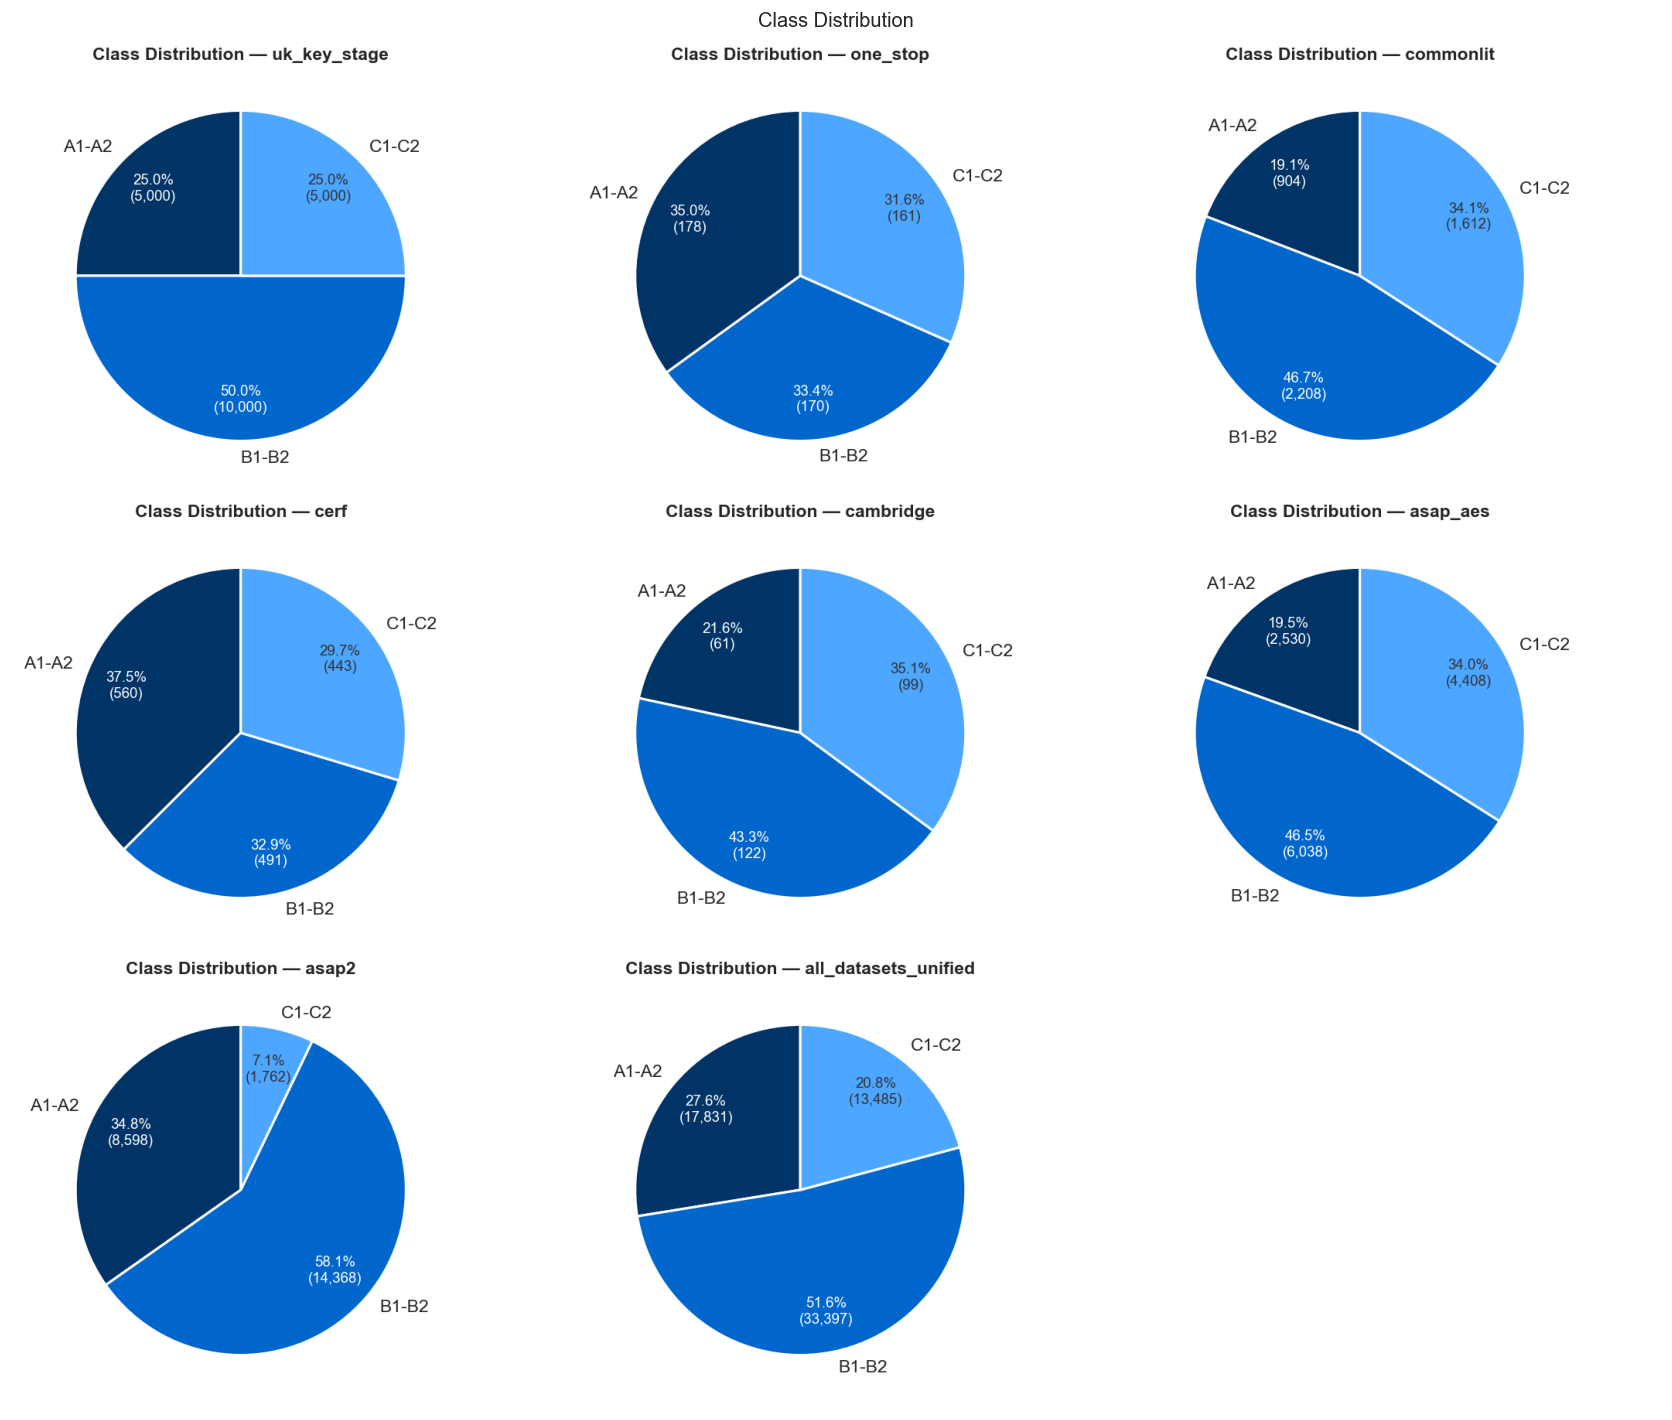

Displayed existing plot: outputs/eda/eda_class_distribution_pie.png


In [23]:
# ── 2.4 plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png"

if display_saved_plot(plot_path, title="Class Distribution", figsize=(15, 12)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for ax, (name, df) in zip(axes, list(datasets.items())+[('all_datasets_unified', all_datasets_unified)]):
        counts = df["label"].value_counts().reindex(CLASSES, fill_value=0)

        _, _, autotexts = ax.pie(
            counts.values,
            labels=CLASSES,
            colors=COLORS,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * counts.sum() / 100)):,})",
            startangle=90,
            pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )

        for i, t in enumerate(autotexts):
            t.set_fontsize(9)
            t.set_color("white" if COLORS[i] in ["#003366", "#0066CC"] else "#333333")

        ax.set_title(f"Class Distribution — {name}", fontsize=11, fontweight="bold")

    for ax in axes[len(datasets):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

In [24]:
# ── compute text length ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        df["text_len"] = df["text"].str.split().str.len()
    
    all_datasets_unified["text_len"] = all_datasets_unified["text"].str.split().str.len()

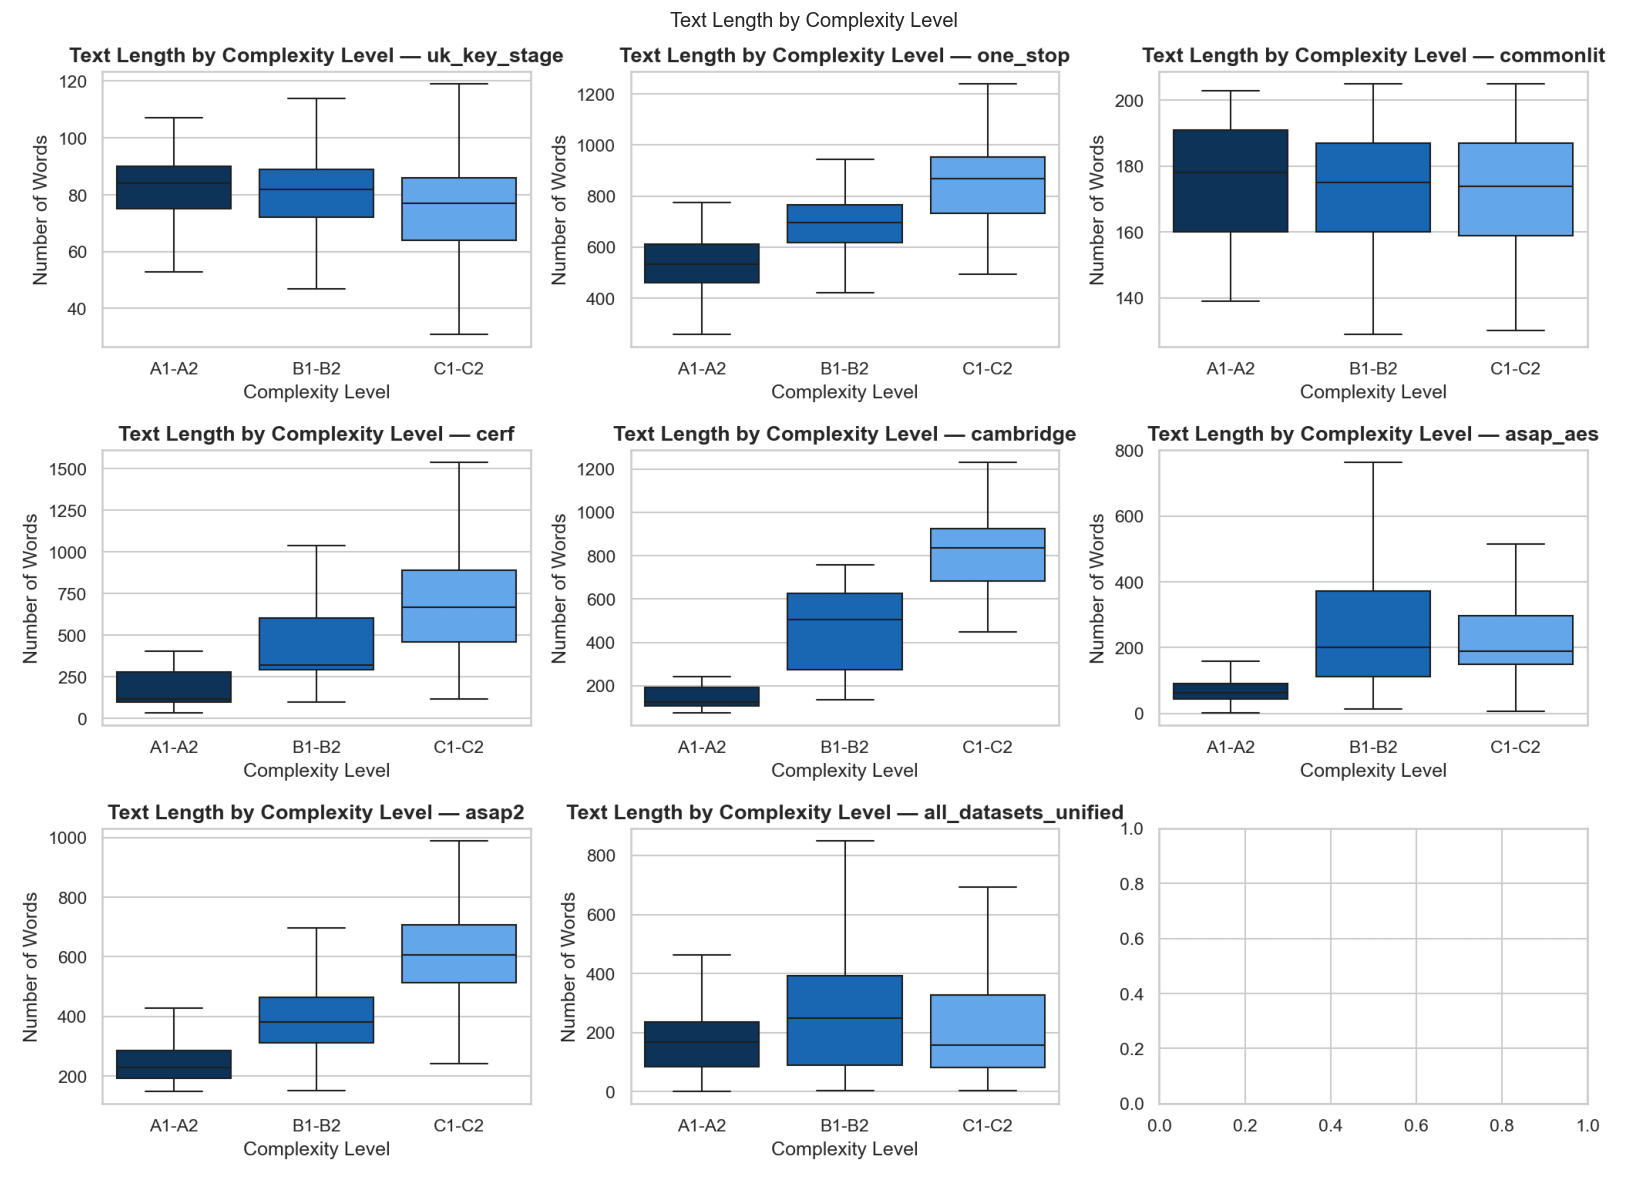

Displayed existing plot: outputs/eda/eda_text_length_by_class.png


In [25]:
# ── 2.5 plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"

if display_saved_plot(plot_path, title="Text Length by Complexity Level", figsize=(14, 10)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (name, df) in zip(axes, list(datasets.items()) + [('all_datasets_unified', all_datasets_unified)]):
        sns.boxplot(
            data=df,
            x="label",
            y="text_len",
            order=CLASSES,
            palette=COLORS,
            ax=ax,
            showfliers=False
        )
        ax.set_title(f"Text Length by Complexity Level — {name}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Complexity Level")
        ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

More difficul text seem to be longer.

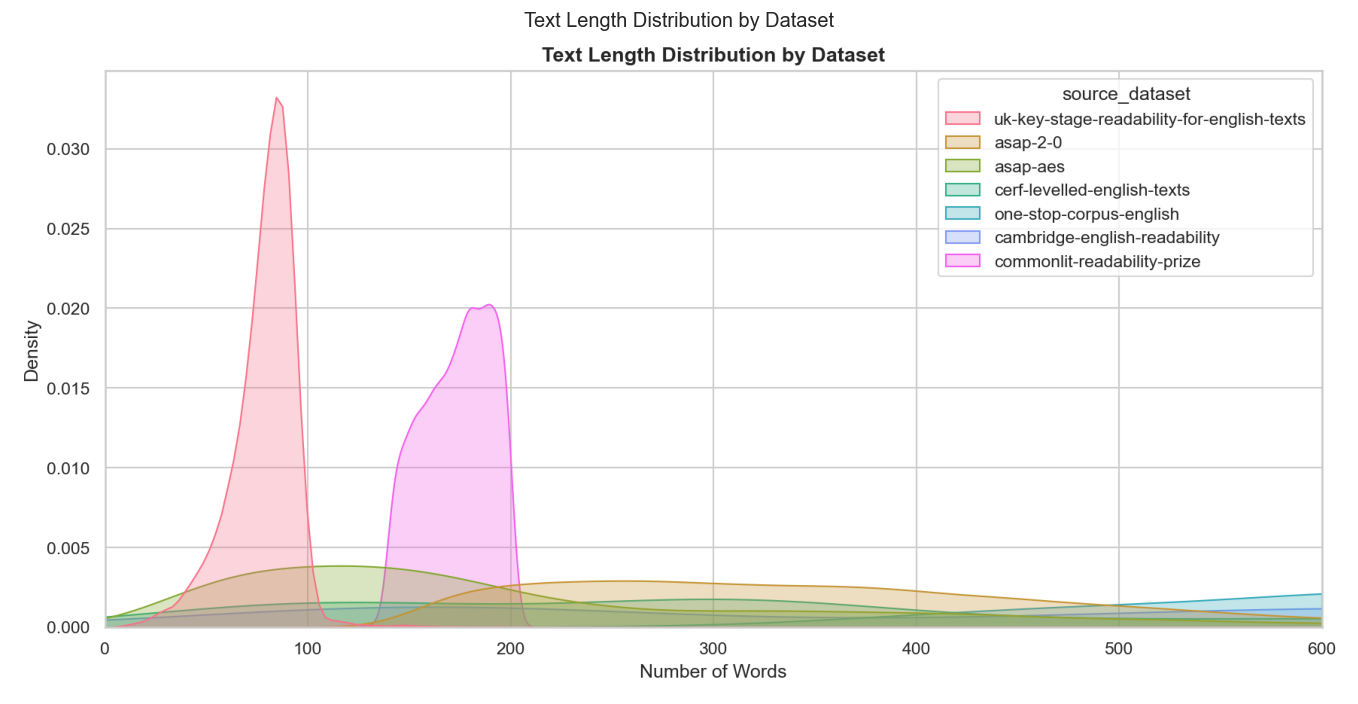

Displayed existing plot: outputs/eda/eda_length_distribution_by_dataset.png


In [26]:
# ── 2.6 plot_path = CFG["output_paths"]["eda"] / "eda_length_distribution_by_dataset.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_length_distribution_by_dataset.png"

if display_saved_plot(plot_path, title="Text Length Distribution by Dataset", figsize=(12, 6)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, ax = plt.subplots(figsize=(12, 6))

    sns.kdeplot(
        data=all_datasets_unified,
        x="text_len",
        hue="source_dataset",
        fill=True,
        alpha=0.3,
        clip=(0, 600),
        common_norm=False,
        ax=ax
    )

    ax.set_title("Text Length Distribution by Dataset", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 600)

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

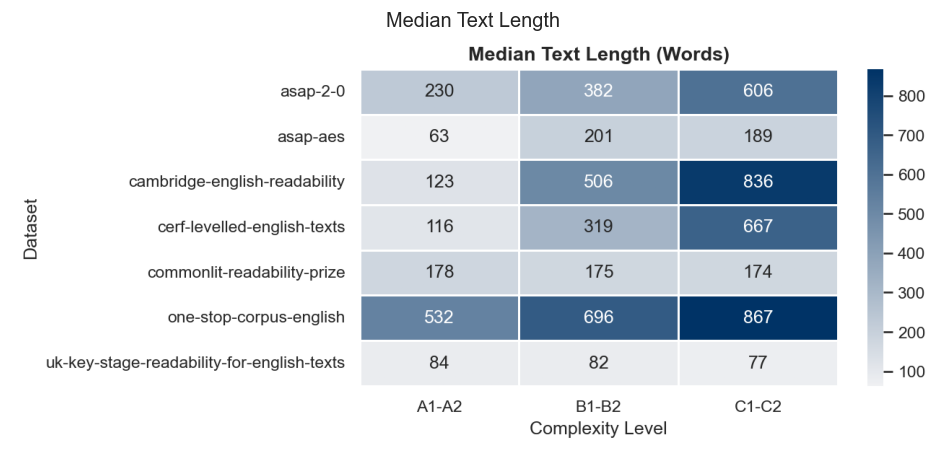

Displayed existing plot: outputs/eda/eda_median_length_heatmap.png


In [27]:
# ── 2.7 plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png"

if display_saved_plot(plot_path, title="Median Text Length", figsize=(9, 4)):
    print(f"Displayed existing plot: {plot_path}")
else:
    median_len = (
        all_datasets_unified
        .groupby(["source_dataset", "label"])["text_len"]
        .median()
        .unstack()
        .reindex(columns=CLASSES)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(
        median_len,
        annot=True,
        fmt=".0f",
        cmap=sns.light_palette(COLORS[0], as_cmap=True),
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )

    ax.set_title("Median Text Length (Words)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Complexity Level")
    ax.set_ylabel("Dataset")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

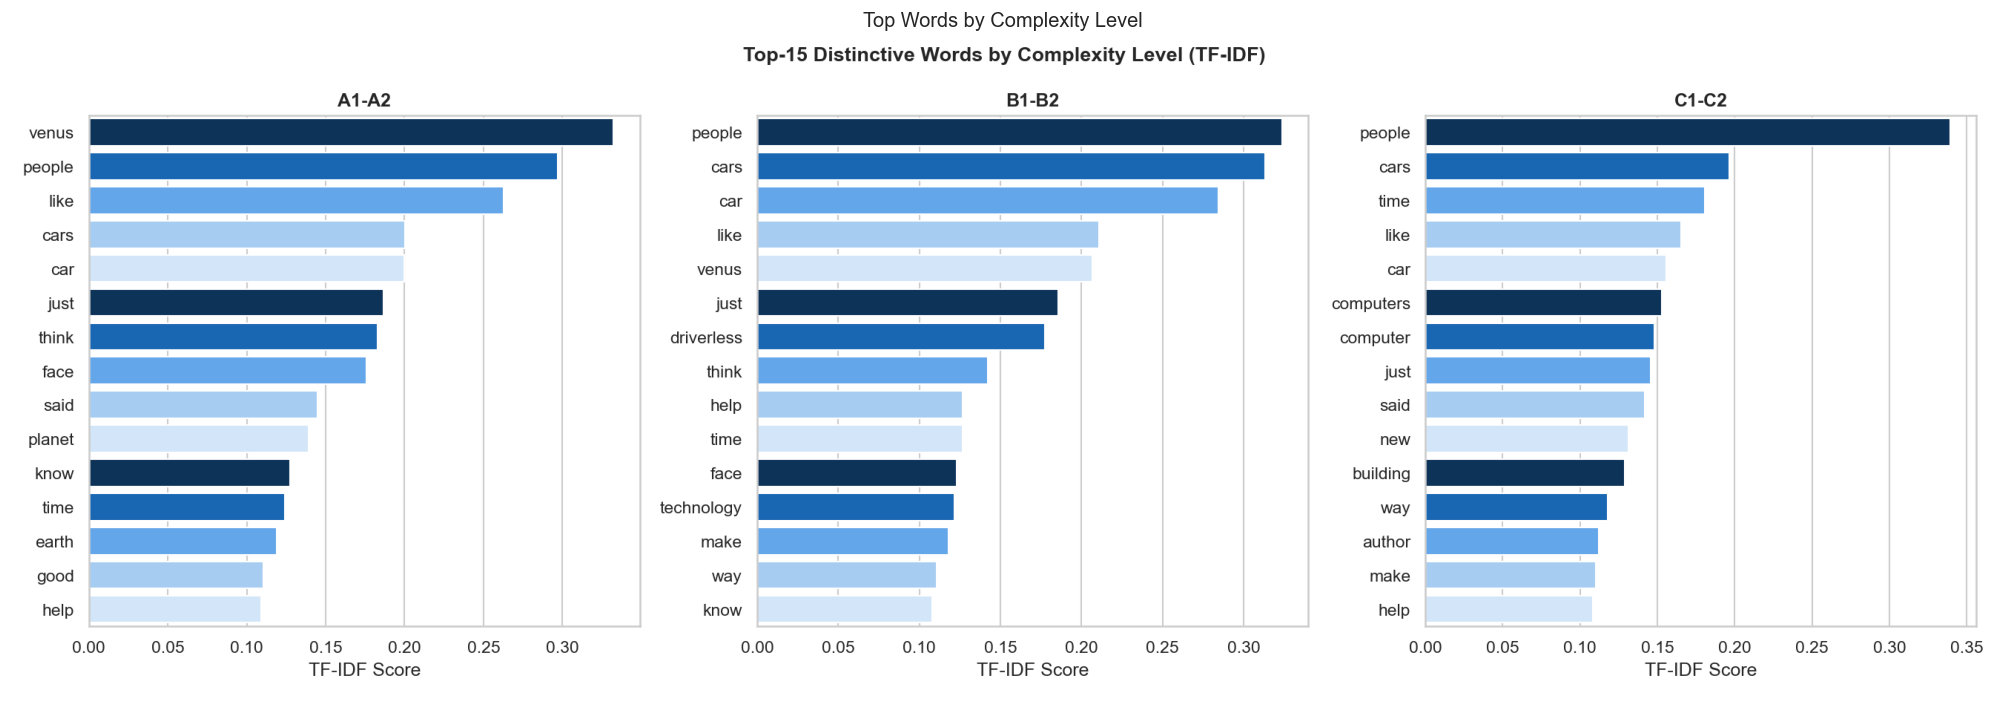

Displayed existing plot: outputs/eda/eda_top_words_tfidf.png


In [28]:
# ── 2.8 plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"

if display_saved_plot(plot_path, title="Top Words by Complexity Level", figsize=(18, 6)):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 6))

    for ax, cls in zip(axes, CLASSES):
        top = get_top_words_tfidf(all_datasets_unified, cls)
        sns.barplot(data=top, y="word", x="score", ax=ax, palette=CONSULTING_COLORS[:len(top)])
        ax.set_title(cls, fontsize=12, fontweight="bold")
        ax.set_xlabel("TF-IDF Score")
        ax.set_ylabel("")

    fig.suptitle(
        "Top-15 Distinctive Words by Complexity Level (TF-IDF)",
        fontsize=13,
        fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

## Results

- The exploratory analysis showed that UK Key Stage and ASAP 2.0 are the largest datasets and together provide the majority of training samples. Therefore, these two datasets will form the main training pool.
- This pool will be divided into subsets for training, validation, and internal testing using readability class stratification.
- The remaining datasets will be reserved for external cross-dataset evaluation only.
- This setup allows us to assess both in-domain performance on similar data and generalization ability on unseen corpora.

---
<a id="section-3-data-preparation"></a>
# SECTION 3 — Data Preparation

We clean the text, align the labels, and prepare comparable splits.
We get reusable train, validation, and test sets for every model family, so the later scores stay directly comparable.


<a id="section-3-1-preprocessing-steps"></a>
## 3.1 Preprocessing Steps


In [29]:
# ── 3.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets.items():
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping preprocessing (CFG['run_data_prep']=False)")

Skipping preprocessing (CFG['run_data_prep']=False)


In [30]:
# ── 3.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")

Skipping dataset cleaning (CFG['run_data_prep']=False)


In [31]:
# ── 3.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}

In [32]:
# ── 3.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets.items():
        df["label_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding for datasets (CFG['run_data_prep']=False)")

Skipping label encoding for datasets (CFG['run_data_prep']=False)


<a id="section-3-2-train-val-test-split"></a>
## 3.2 Train/Val/Test Split


In [33]:
# ── 3.6 create training pool split ─────────────────────────────────────────
if CFG["run_data_prep"]:
    train_pool_keys = CFG.get("train_pool_datasets", ["uk_key_stage", "asap2"])
    missing_datasets = [name for name in train_pool_keys if name not in datasets]

    if missing_datasets:
        raise ValueError(f"Missing required datasets: {missing_datasets}")

    train_pool = (
        pd.concat([datasets[name].copy() for name in train_pool_keys], ignore_index=True)
        .sample(frac=1, random_state=CFG["seed"])
        .reset_index(drop=True)
    )

    required_cols = ["text_raw", "text_clean", CFG.get("encoded_label_col", "label_enc")]
    missing_cols = [c for c in required_cols if c not in train_pool.columns]
    if missing_cols:
        raise ValueError(f"train_pool: missing columns {missing_cols}")

    train_pool_target_col = resolve_target_col(train_pool, CFG)
    if train_pool_target_col not in train_pool.columns:
        raise ValueError(f"train_pool: missing target column {train_pool_target_col!r}.")

    splits = {
        CFG["train_pool_key"]: make_splits_and_arrays(train_pool, CFG)
    }

    train_pool_split = splits[CFG["train_pool_key"]]
    print(
        f"{CFG['train_pool_key']} ({' + '.join(train_pool_keys)}) -> "
        f"Train: {len(train_pool_split['df_train'])} | "
        f"Val: {len(train_pool_split['df_val'])} | Test: {len(train_pool_split['df_test'])}"
    )

    external_eval_keys = CFG.get("external_eval_dataset_keys")
    if external_eval_keys:
        missing_external = [name for name in external_eval_keys if name not in datasets]
        if missing_external:
            raise ValueError(f"Missing external evaluation datasets: {missing_external}")
    else:
        external_eval_keys = [name for name in datasets if name not in train_pool_keys]

    external_eval_datasets = {
        name: datasets[name].copy() for name in external_eval_keys
    }
    external_eval_summary_df = pd.DataFrame(
        [
            {
                "dataset": name,
                "rows": len(df),
                "classes": ', '.join(sorted(df[CFG["label_col"]].dropna().astype(str).unique().tolist())),
            }
            for name, df in external_eval_datasets.items()
        ]
    ).sort_values(["rows", "dataset"], ascending=[False, True]).reset_index(drop=True)

    print("\nExternal evaluation datasets:")
    display(external_eval_summary_df)

    cv = StratifiedKFold(
        n_splits=CFG["cv_folds"],
        shuffle=True,
        random_state=CFG["seed"]
    )
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")

Skipping split creation (CFG['run_data_prep']=False)


In [34]:
# ── 3.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    split_artifacts = {
        "splits": splits,
        "train_pool_sources": train_pool_keys,
        "external_eval_datasets": external_eval_datasets,
        "external_eval_summary_df": external_eval_summary_df,
    }

    with open(CFG["split_artifact_path"], "wb") as f:
        pickle.dump(split_artifacts, f)
else:
    print("Skipping split serialization (CFG['run_data_prep']=False)")

Skipping split serialization (CFG['run_data_prep']=False)


In [35]:
# ── 3.8 load split artifacts ─────────────────────────────────────────
split_artifacts = locals().get("split_artifacts")

if not split_artifacts:
    split_artifacts = load_pickle_with_fallback(CFG["split_artifact_path"])

splits = split_artifacts["splits"]
train_pool_key = CFG.get("train_pool_key", "train_pool")
train_pool_split = splits[train_pool_key]
train_pool_sources = split_artifacts.get("train_pool_sources", CFG.get("train_pool_datasets", []))
external_eval_datasets = split_artifacts["external_eval_datasets"]
external_eval_summary_df = split_artifacts.get("external_eval_summary_df")
if external_eval_summary_df is None:
    external_eval_summary_df = pd.DataFrame(
        [
            {
                "dataset": name,
                "rows": len(df),
                "classes": ', '.join(sorted(df[CFG["label_col"]].dropna().astype(str).unique().tolist())),
            }
            for name, df in external_eval_datasets.items()
        ]
    ).sort_values(["rows", "dataset"], ascending=[False, True]).reset_index(drop=True)

external_eval_bundles = {
    name: build_transformer_eval_bundle_from_df(df, dataset_name=name)
    for name, df in external_eval_datasets.items()
}
display(external_eval_summary_df)

Loaded pickle: data/complexity_splits.pkl
one_stop: eval=507
commonlit: eval=4,723
cerf: eval=1,493
cambridge: eval=274
asap_aes: eval=12,972


,dataset,rows,classes
0,asap_aes,12972,"A1-A2, B1-B2, C1-C2"
1,commonlit,4723,"A1-A2, B1-B2, C1-C2"
2,cerf,1493,"A1-A2, B1-B2, C1-C2"
3,one_stop,507,"A1-A2, B1-B2, C1-C2"
4,cambridge,274,"A1-A2, B1-B2, C1-C2"


---
<a id="section-4-baseline-models"></a>
# SECTION 4 — Baseline Models

We start with simple baselines to anchor the task.
We get learning curves and test metrics on the shared in-domain training pool split, and we can see the first gains before moving to heavier models.


Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  

<a id="section-4-1-preparation-architecture"></a>
## 4.1 Preparation & Architecture


In [36]:
le = DictLabelEncoder(class2id)

In [37]:
# -- 4.1 baseline_models = build_baseline_pipeline_models(CFG) ---------
baseline_models = build_baseline_pipeline_models(CFG)

best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"

if best_models_cache.exists() and tuning_cache.exists():
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")
else:
    best_baseline_models, baseline_tuning_df = tune_baselines_on_reference_split(
        models=baseline_models,
        split=train_pool_split,
        seed=CFG["seed"],
        n_iter=4,
    )
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df, tuning_cache)
    print(f"Best baseline selection completed on {train_pool_key} (validation split).")

le = DictLabelEncoder(class2id)
display(baseline_tuning_df)


Loaded cached baseline tuning artefacts -> skipping retuning.


,model,params,val_f1_macro,selected,note
0,Majority Class,fixed,NaN,True,kept fixed
1,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.630562,False,candidate
2,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.628270,False,candidate
3,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.645385,False,candidate
4,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.663830,False,candidate
5,TF-IDF + LogReg,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.663830,True,best_on_reference_val
6,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.645955,False,candidate
7,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 2), 'tfidf__max_fea...",0.629648,False,candidate
8,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.671581,False,candidate
9,TF-IDF + SVC,"{'tfidf__ngram_range': (1, 1), 'tfidf__max_fea...",0.645955,False,candidate


<a id="section-4-2-training"></a>
## 4.2 Training


In [38]:
# -- 4.2 Train baseline models on the shared train-pool split ---------------
baseline_split_keys = [train_pool_key]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=baseline_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key=train_pool_key,
)

Baseline train/eval:   0%|          | 0/4 [00:00<?, ?it/s]


  Majority Class [train_pool] | VAL
  Accuracy      : 0.5448
  F1 (macro)    : 0.2351
  F1 (weighted) : 0.3843

              precision    recall  f1-score   support

       A1-A2       0.00      0.00      0.00      2040
       B1-B2       0.54      1.00      0.71      3655
       C1-C2       0.00      0.00      0.00      1014

    accuracy                           0.54      6709
   macro avg       0.18      0.33      0.24      6709
weighted avg       0.30      0.54      0.38      6709


  Majority Class [train_pool] | TEST
  Accuracy      : 0.5448
  F1 (macro)    : 0.2351
  F1 (weighted) : 0.3843

              precision    recall  f1-score   support

       A1-A2       0.00      0.00      0.00      2040
       B1-B2       0.54      1.00      0.71      3655
       C1-C2       0.00      0.00      0.00      1014

    accuracy                           0.54      6709
   macro avg       0.18      0.33      0.24      6709
weighted avg       0.30      0.54      0.38      6709

Final valid

<a id="section-4-3-results"></a>
## 4.3 Results


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,model_tag,model_path,status
0,Majority Class,train_pool,31305,test,0.544791,0.235109,0.384255,NaN,Majority Class [train_pool],models/majority_class_complexity_train_pool_20...,loaded
1,Majority Class,train_pool,31305,val,0.544791,0.235109,0.384255,NaN,Majority Class [train_pool],models/majority_class_complexity_train_pool_20...,loaded
2,TF-IDF + LogReg,train_pool,31305,test,0.683559,0.660787,0.686397,NaN,TF-IDF + LogReg [train_pool],models/tf_idf_logreg_complexity_train_pool_202...,loaded
3,TF-IDF + LogReg,train_pool,31305,val,0.687435,0.663830,0.690420,NaN,TF-IDF + LogReg [train_pool],models/tf_idf_logreg_complexity_train_pool_202...,loaded
4,TF-IDF + SVC,train_pool,31305,test,0.700253,0.668679,0.699787,NaN,TF-IDF + SVC [train_pool],models/tf_idf_svc_complexity_train_pool_202603...,loaded
5,TF-IDF + SVC,train_pool,31305,val,0.703384,0.671581,0.703144,NaN,TF-IDF + SVC [train_pool],models/tf_idf_svc_complexity_train_pool_202603...,loaded
6,TF-IDF + XGBoost,train_pool,31305,test,0.673871,0.534221,0.634389,NaN,TF-IDF + XGBoost [train_pool],models/tf_idf_xgboost_complexity_train_pool_20...,loaded
7,TF-IDF + XGBoost,train_pool,31305,val,0.683858,0.551168,0.647103,NaN,TF-IDF + XGBoost [train_pool],models/tf_idf_xgboost_complexity_train_pool_20...,loaded


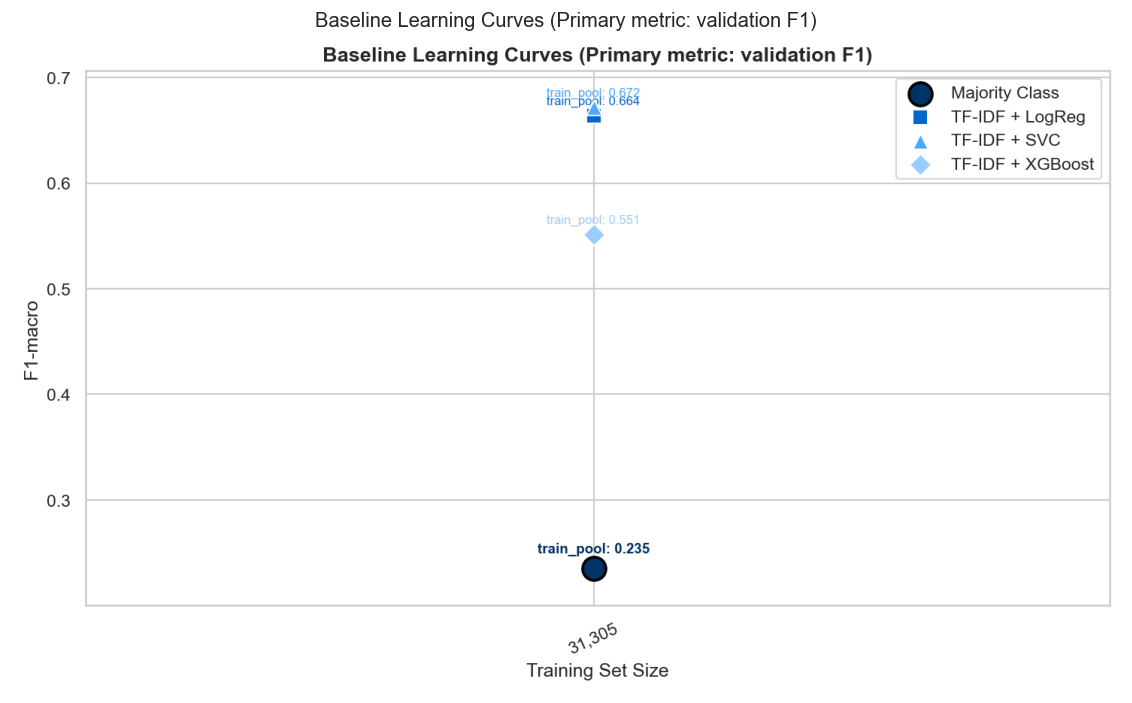

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


In [39]:
# -- 4.3 Baseline internal metrics and artefacts -----------------------------
display(
    baseline_eval_df
    .sort_values(["model", "split", "train_size"])
    .reset_index(drop=True)
)

plot_learning_curve_from_metrics(
    baseline_curve_df,
    title="Baseline Learning Curves (Primary metric: validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)

metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}


---
<a id="section-5-static-embeddings-models"></a>
# SECTION 5 — Static Embeddings + Models (FastText, MLP + CNN)

We move to fixed embeddings with lightweight neural models.
We get shared vocab and embedding artefacts plus MLP and CNN runs, and we can already check how much extra capacity helps once the data grow.


<a id="section-5-1-preparation-architecture"></a>
## 5.1 Preparation & Architecture

Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).


**Architecture:**
- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).  
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

In [40]:
# -- 5.1 Prepare shared vocabulary, embeddings, and loaders -----------------
complexity_split_keys_dl = [train_pool_key]
base_split_key_dl = train_pool_key

base_split = splits[base_split_key_dl]
X_train, X_val, X_test = base_split["X_train"], base_split["X_val"], base_split["X_test"]
X_train_raw, X_val_raw, X_test_raw = base_split["X_train_raw"], base_split["X_val_raw"], base_split["X_test_raw"]
y_train, y_val, y_test = base_split["y_train"], base_split["y_val"], base_split["y_test"]
df_train, df_val, df_test = base_split["df_train"], base_split["df_val"], base_split["df_test"]

print(
    f"{base_split_key_dl}: train={len(X_train):,} | "
    f"val={len(X_val):,} | test={len(X_test):,}"
)
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")

vocab = build_vocab(
    X_train,
    max_vocab=CFG["vocab_size"],
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)
print(f"Vocabulary size: {len(vocab):,}")

vocab_words = set(vocab.keys())
total = 0
oov = 0
for text in X_val:
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)
if total:
    print(f"OOV rate: {oov / total:.2%}  ({oov}/{total})")

if CFG.get("dl_train_mode", True):
    embedding_matrix = load_embedding_matrix(
        vocab, CFG["embedding_model"], CFG["embedding_dim"]
    )
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
else:
    embedding_matrix = None
    print("Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.")

seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val = texts_to_sequences(X_val, vocab, CFG["max_seq_len"])
seq_test = texts_to_sequences(X_test, vocab, CFG["max_seq_len"])
print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"],
)
print("Base split DataLoaders ready.")

dl_split_data = {
    base_split_key_dl: {
        "loader_train": loader_train,
        "loader_val": loader_val,
        "loader_test": loader_test,
        "y_val": y_val,
        "y_test": y_test,
        "df_test": df_test,
        "train_size": len(X_train),
    }
}
print("Shared deep-learning split DataLoaders ready.")

CMAP = sns.light_palette(COLORS[0], as_cmap=True)

DEEP_MODEL_SPECS = {
    "GloVe MLP": {
        "family_slug": "glove_mlp",
        "builder": lambda: EmbeddingMLP(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=256,
            dropout=CFG["dropout"],
        ),
    },
    "GloVe CNN": {
        "family_slug": "glove_cnn",
        "builder": lambda: TextCNN(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            num_filters=CFG["cnn_num_filters"],
            kernel_sizes=CFG["cnn_kernel_sizes"],
            dropout=CFG["dropout"],
        ),
    },
    "GloVe BiLSTM": {
        "family_slug": "glove_bilstm",
        "builder": lambda: BiLSTMAttention(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=CFG["lstm_hidden_dim"],
            num_layers=CFG["lstm_num_layers"],
            dropout=CFG["dropout"],
        ),
    },
}


train_pool: train=31,305 | val=6,709 | test=6,709
Base split for shared vocabulary/embeddings: train_pool
Vocabulary size: 50,000
OOV rate: 4.96%  (41341/832998)
Loading fasttext-wiki-news-subwords-300 ...


INFO:gensim.models.keyedvectors:loading projection weights from /Users/georgijkutivadze/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz
INFO:gensim.utils:KeyedVectors lifecycle event {'msg': 'loaded (999999, 300) matrix of type float32 from /Users/georgijkutivadze/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2026-03-07T20:28:31.824358', 'gensim': '4.4.0', 'python': '3.11.11 | packaged by conda-forge | (main, Dec  5 2024, 08:47:03) [Clang 18.1.8 ]', 'platform': 'macOS-26.3.1-arm64-arm-64bit', 'event': 'load_word2vec_format'}


Coverage: 49.3%  (hits=24643, misses=25357)
Embedding matrix shape: (50000, 300)
seq_train: (31305, 256) | seq_val: (6709, 256) | seq_test: (6709, 256)
Base split DataLoaders ready.
Shared deep-learning split DataLoaders ready.


<a id="section-5-2-training"></a>
## 5.2 Training

Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.



===== GloVe MLP | train_pool =====
GloVe MLP [train_pool]: best checkpoint found -> skip retraining (models/glove_mlp_complexity_train_pool_20260307_163101/best_model/best.pt)


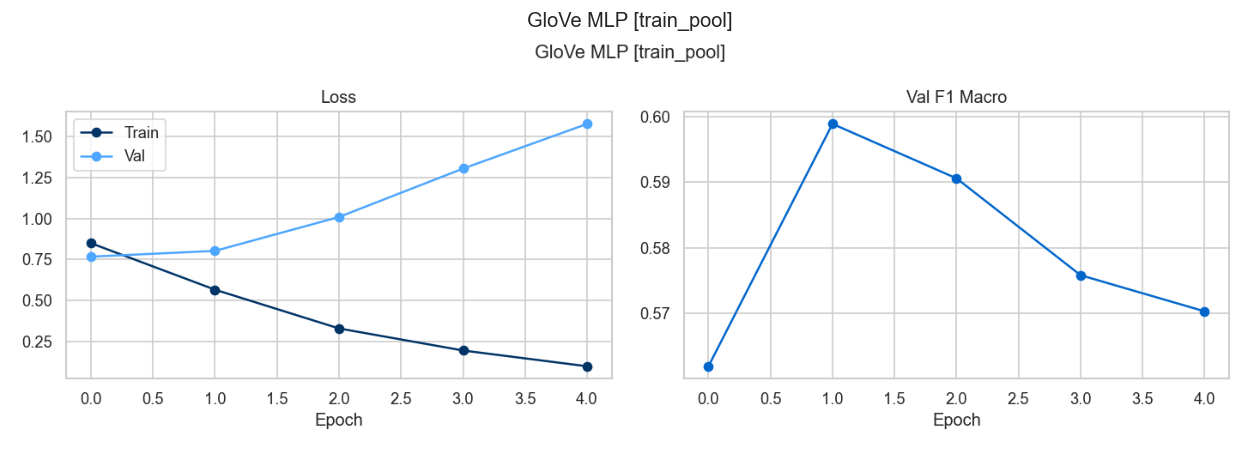

Displayed existing training curve: outputs/plots/histories/history_glove_mlp_train_pool.png

  GloVe MLP [train_pool] | VAL
  Accuracy      : 0.6549
  F1 (macro)    : 0.5989
  F1 (weighted) : 0.6457

              precision    recall  f1-score   support

       A1-A2       0.66      0.51      0.58      2040
       B1-B2       0.67      0.80      0.73      3655
       C1-C2       0.57      0.43      0.49      1014

    accuracy                           0.65      6709
   macro avg       0.63      0.58      0.60      6709
weighted avg       0.65      0.65      0.65      6709

Final validation F1 (macro) [GloVe MLP [train_pool]]: 0.5989

  GloVe MLP [train_pool] | TEST
  Accuracy      : 0.6527
  F1 (macro)    : 0.5964
  F1 (weighted) : 0.6427

              precision    recall  f1-score   support

       A1-A2       0.66      0.49      0.56      2040
       B1-B2       0.66      0.80      0.73      3655
       C1-C2       0.56      0.45      0.50      1014

    accuracy                   

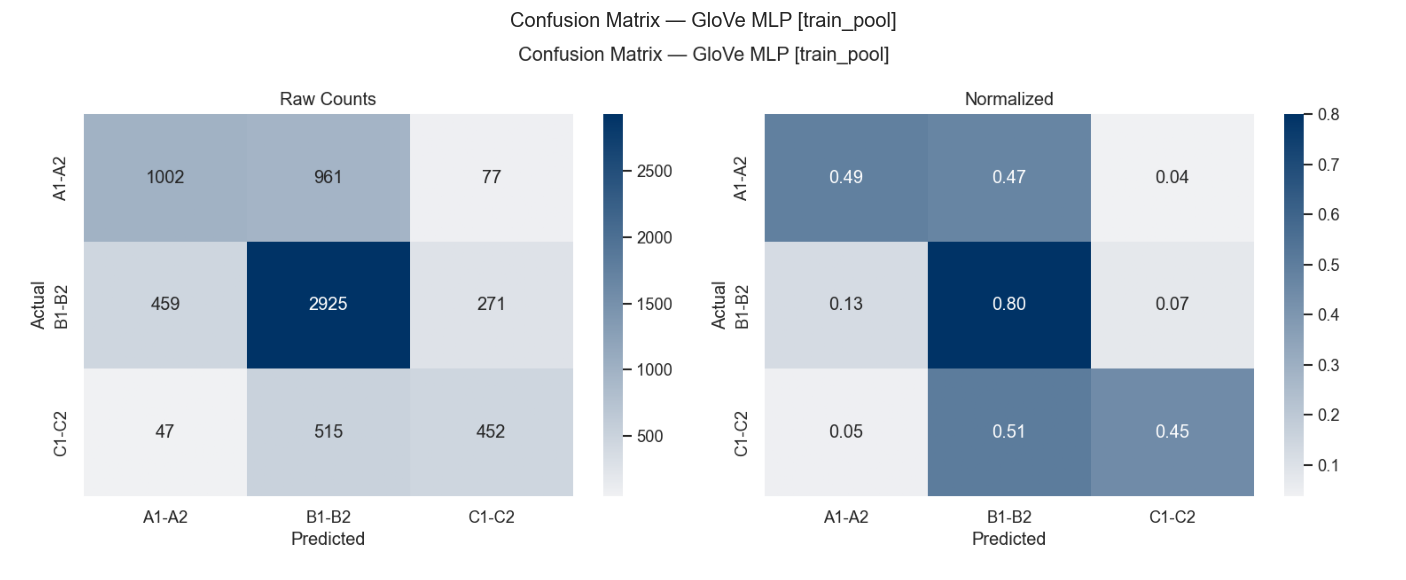

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_train_pool.png

===== GloVe CNN | train_pool =====
GloVe CNN [train_pool]: best checkpoint found -> skip retraining (models/glove_cnn_complexity_train_pool_20260307_163151/best_model/best.pt)


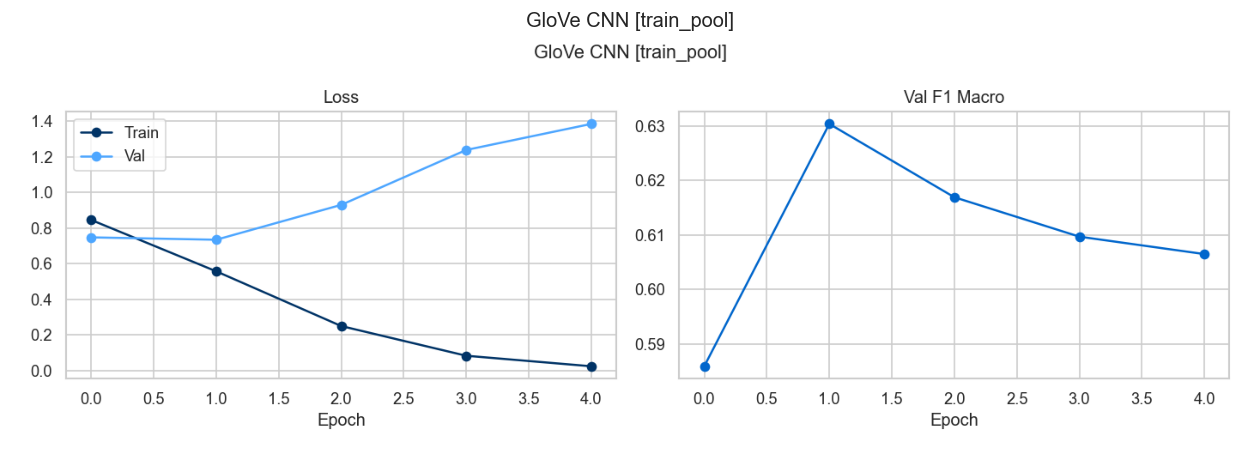

Displayed existing training curve: outputs/plots/histories/history_glove_cnn_train_pool.png

  GloVe CNN [train_pool] | VAL
  Accuracy      : 0.6745
  F1 (macro)    : 0.6304
  F1 (weighted) : 0.6712

              precision    recall  f1-score   support

       A1-A2       0.70      0.58      0.63      2040
       B1-B2       0.70      0.77      0.73      3655
       C1-C2       0.54      0.51      0.52      1014

    accuracy                           0.67      6709
   macro avg       0.64      0.62      0.63      6709
weighted avg       0.67      0.67      0.67      6709

Final validation F1 (macro) [GloVe CNN [train_pool]]: 0.6304

  GloVe CNN [train_pool] | TEST
  Accuracy      : 0.6795
  F1 (macro)    : 0.6388
  F1 (weighted) : 0.6767

              precision    recall  f1-score   support

       A1-A2       0.70      0.57      0.63      2040
       B1-B2       0.70      0.78      0.74      3655
       C1-C2       0.54      0.55      0.55      1014

    accuracy                   

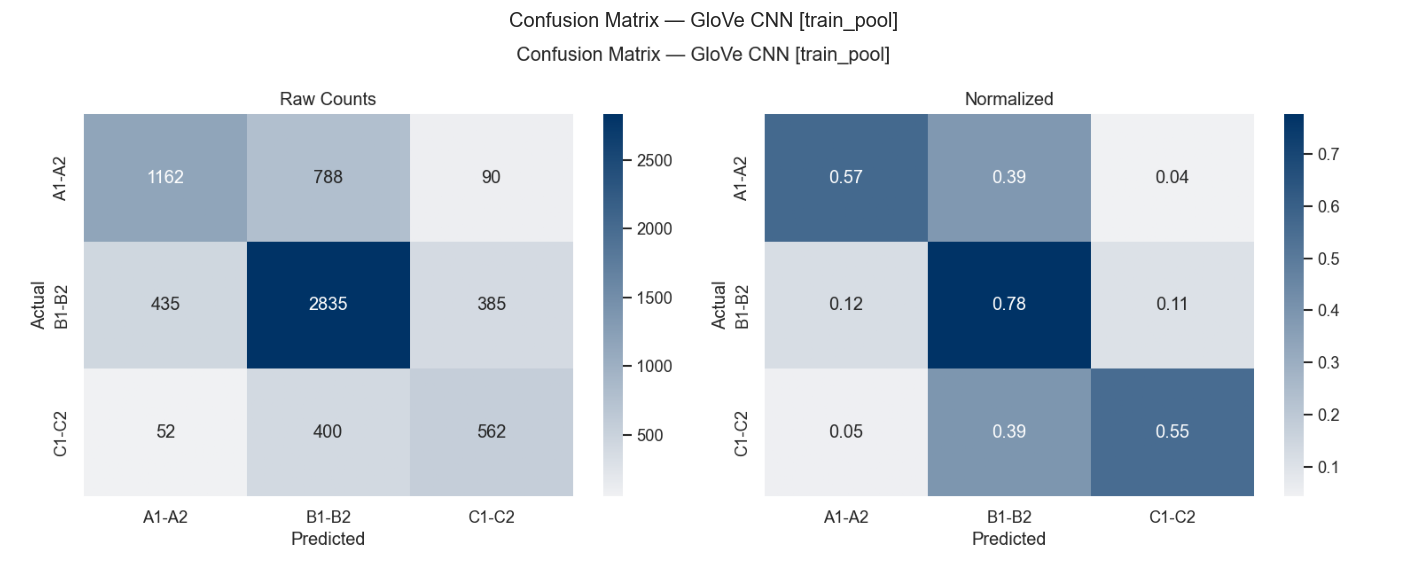

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_cnn_train_pool.png


In [41]:
# -- 5.2 Train GloVe MLP and GloVe CNN on the shared split ------------------
deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}
DEEP_RUNS = {}

for model_label in ["GloVe MLP", "GloVe CNN"]:
    print()
    print(f"===== {model_label} | {train_pool_key} =====")
    split_data = dl_split_data[train_pool_key]
    model_spec = DEEP_MODEL_SPECS[model_label]

    model_obj, history, val_metrics, test_metrics, test_preds = run_torch_experiment(
        model_label=model_label,
        family_slug=model_spec["family_slug"],
        split_key=train_pool_key,
        split_data=split_data,
        model_builder=model_spec["builder"],
        label_encoder=le,
    )

    exp_paths = resolve_experiment_paths(
        model_family=model_spec["family_slug"],
        dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
        size_tag=size_tag_from_split(train_pool_key),
        model_root=CFG["model_dir"],
    )

    run_name = f"{model_label} [{train_pool_key}]"
    deep_histories[run_name] = history
    deep_test_preds[run_name] = test_preds
    DEEP_RUNS[model_label] = {
        "model": model_obj,
        "history": history,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
        "test_preds": test_preds,
        "best_checkpoint": str(exp_paths["best_model"] / "best.pt"),
    }

    deep_curve_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": model_label,
        "split_key": train_pool_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    plot_confusion_matrix_clf(split_data["y_test"], test_preds, run_name, le)


---
<a id="section-6-recurrent-models-bilstm-bigru"></a>
# SECTION 6 — Recurrent Models (BiLSTM / BiGRU)

We add a recurrent model on the same setup.
We get BiLSTM results on the matched splits, and we can judge whether sequence modelling is worth the extra complexity here.


<a id="section-6-1-preparation-architecture"></a>
## 6.1 Preparation & Architecture

**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


<a id="section-6-2-training"></a>
## 6.2 Training



===== GloVe BiLSTM | train_pool =====
GloVe BiLSTM [train_pool]: best checkpoint found -> skip retraining (models/glove_bilstm_complexity_train_pool_20260307_163358/best_model/best.pt)


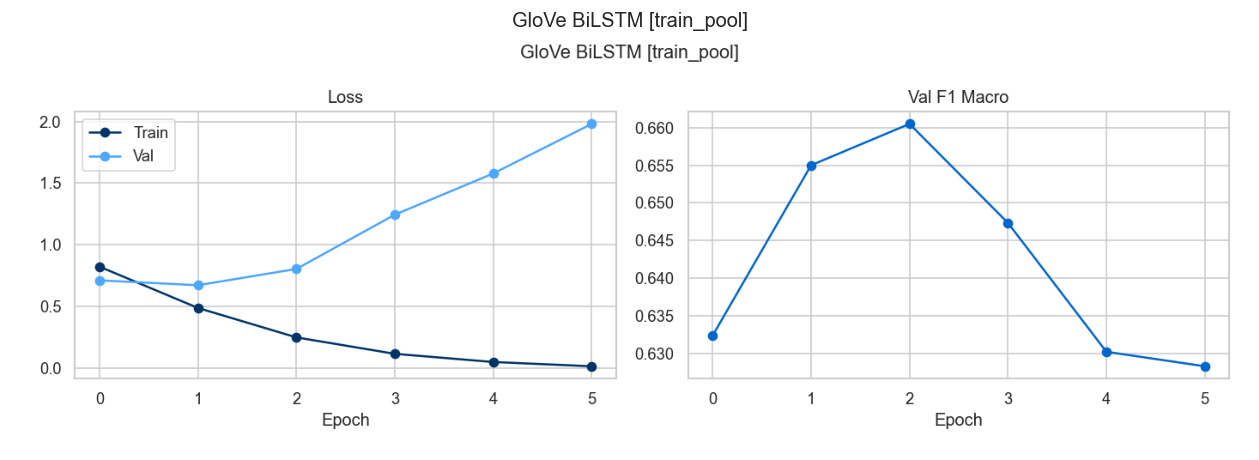

Displayed existing training curve: outputs/plots/histories/history_glove_bilstm_train_pool.png

  GloVe BiLSTM [train_pool] | VAL
  Accuracy      : 0.6830
  F1 (macro)    : 0.6451
  F1 (weighted) : 0.6830

              precision    recall  f1-score   support

       A1-A2       0.72      0.62      0.67      2040
       B1-B2       0.71      0.75      0.73      3655
       C1-C2       0.51      0.56      0.53      1014

    accuracy                           0.68      6709
   macro avg       0.65      0.64      0.65      6709
weighted avg       0.69      0.68      0.68      6709

Final validation F1 (macro) [GloVe BiLSTM [train_pool]]: 0.6451

  GloVe BiLSTM [train_pool] | TEST
  Accuracy      : 0.6927
  F1 (macro)    : 0.6552
  F1 (weighted) : 0.6923

              precision    recall  f1-score   support

       A1-A2       0.74      0.62      0.68      2040
       B1-B2       0.72      0.77      0.74      3655
       C1-C2       0.53      0.57      0.55      1014

    accuracy       

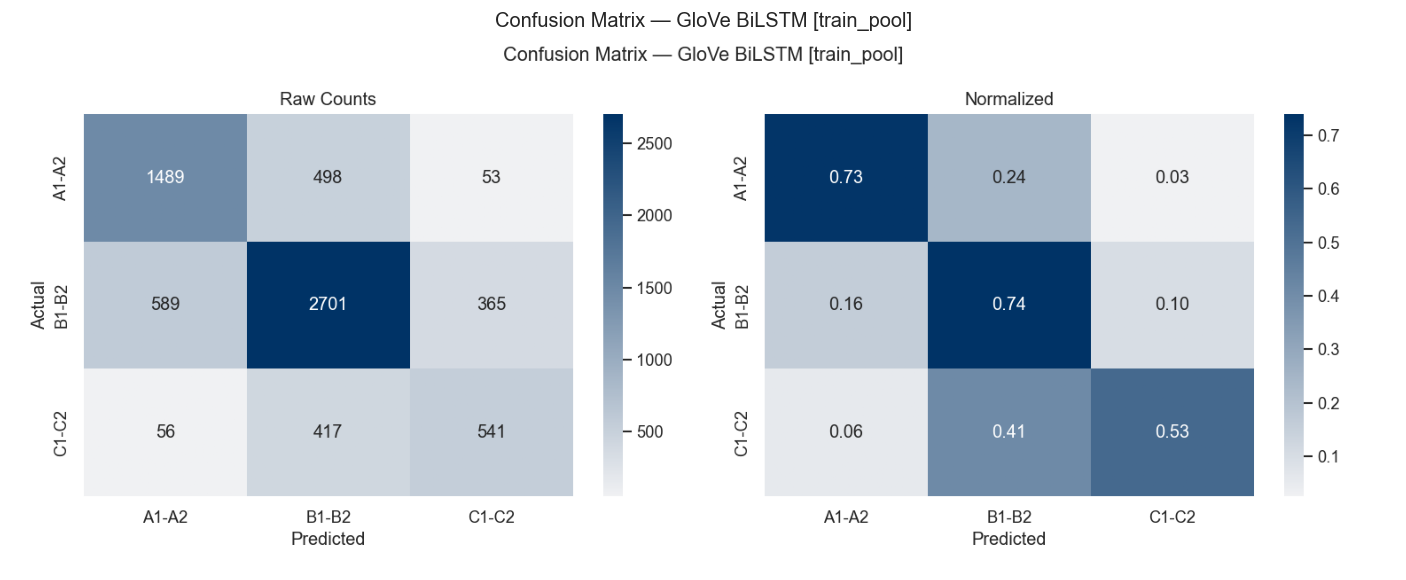

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_bilstm_train_pool.png


In [42]:
# -- 6.2 Train GloVe BiLSTM on the shared split -----------------------------
print()
print(f"===== GloVe BiLSTM | {train_pool_key} =====")
split_data = dl_split_data[train_pool_key]
model_spec = DEEP_MODEL_SPECS["GloVe BiLSTM"]

bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
    model_label="GloVe BiLSTM",
    family_slug=model_spec["family_slug"],
    split_key=train_pool_key,
    split_data=split_data,
    model_builder=model_spec["builder"],
    label_encoder=le,
)

exp_paths = resolve_experiment_paths(
    model_family=model_spec["family_slug"],
    dataset=CFG.get("experiment_dataset_slug", slugify(CFG.get("task", "dataset"))),
    size_tag=size_tag_from_split(train_pool_key),
    model_root=CFG["model_dir"],
)

run_name = f"GloVe BiLSTM [{train_pool_key}]"
deep_histories[run_name] = lstm_history
deep_test_preds[run_name] = bilstm_preds
DEEP_RUNS["GloVe BiLSTM"] = {
    "model": bilstm_model,
    "history": lstm_history,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
    "test_preds": bilstm_preds,
    "best_checkpoint": str(exp_paths["best_model"] / "best.pt"),
}

deep_curve_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "f1_macro": float(val_metrics["f1_macro"]),
})

deep_eval_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "split": "val",
    "accuracy": float(val_metrics.get("accuracy", np.nan)),
    "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
    "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
})
deep_eval_rows.append({
    "model": "GloVe BiLSTM",
    "split_key": train_pool_key,
    "train_size": split_data["train_size"],
    "split": "test",
    "accuracy": float(test_metrics.get("accuracy", np.nan)),
    "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
    "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
})

plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)


<a id="section-6-3-results"></a>
## 6.3 Results


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,train_pool,31305,0.645099
1,GloVe CNN,train_pool,31305,0.630351
2,GloVe MLP,train_pool,31305,0.598906


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,train_pool,31305,val,0.682963,0.645099,0.683047,NaN,GloVe BiLSTM [train_pool] | val
1,GloVe CNN,train_pool,31305,val,0.674467,0.630351,0.671217,NaN,GloVe CNN [train_pool] | val
2,GloVe MLP,train_pool,31305,val,0.654941,0.598906,0.645712,NaN,GloVe MLP [train_pool] | val


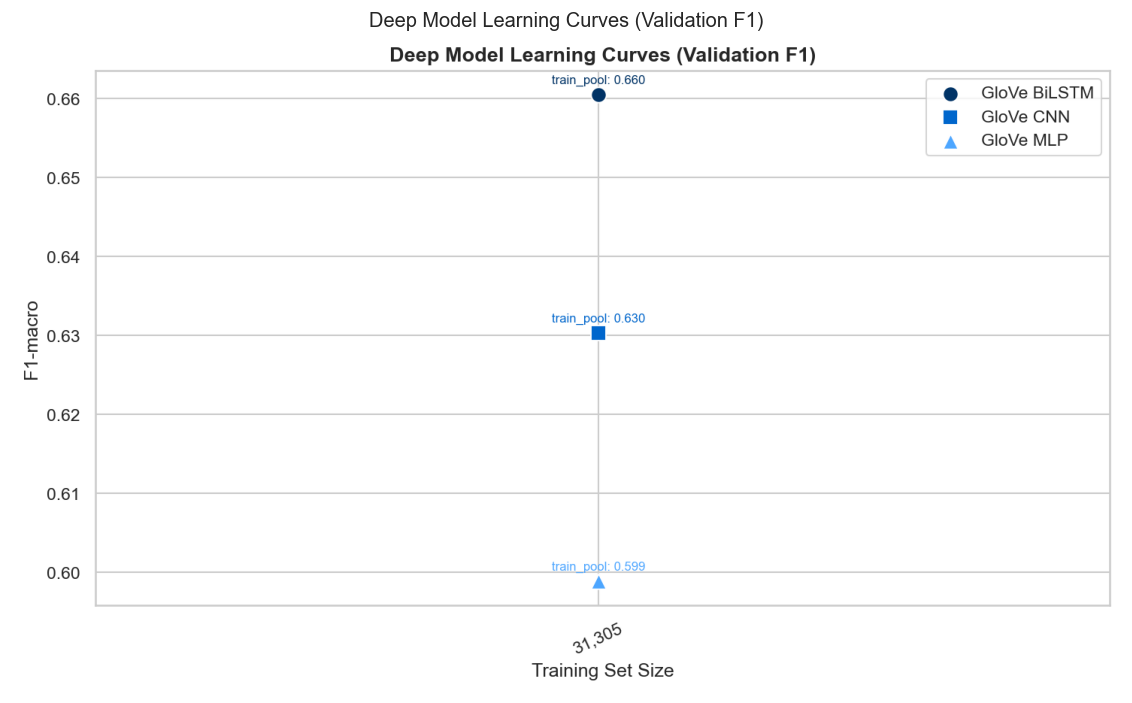

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,train_pool,31305,test,0.692652,0.655166,0.692321,NaN,GloVe BiLSTM [train_pool] | test
1,GloVe BiLSTM,train_pool,31305,val,0.682963,0.645099,0.683047,NaN,GloVe BiLSTM [train_pool] | val
2,GloVe CNN,train_pool,31305,test,0.679535,0.638827,0.676700,NaN,GloVe CNN [train_pool] | test
3,GloVe CNN,train_pool,31305,val,0.674467,0.630351,0.671217,NaN,GloVe CNN [train_pool] | val
4,GloVe MLP,train_pool,31305,test,0.652705,0.596446,0.642675,NaN,GloVe MLP [train_pool] | test
5,GloVe MLP,train_pool,31305,val,0.654941,0.598906,0.645712,NaN,GloVe MLP [train_pool] | val


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,train_pool,31305,0.645099
1,GloVe CNN,train_pool,31305,0.630351
2,GloVe MLP,train_pool,31305,0.598906
3,Majority Class,train_pool,31305,0.235109
4,TF-IDF + LogReg,train_pool,31305,0.663830
5,TF-IDF + SVC,train_pool,31305,0.671581
6,TF-IDF + XGBoost,train_pool,31305,0.551168


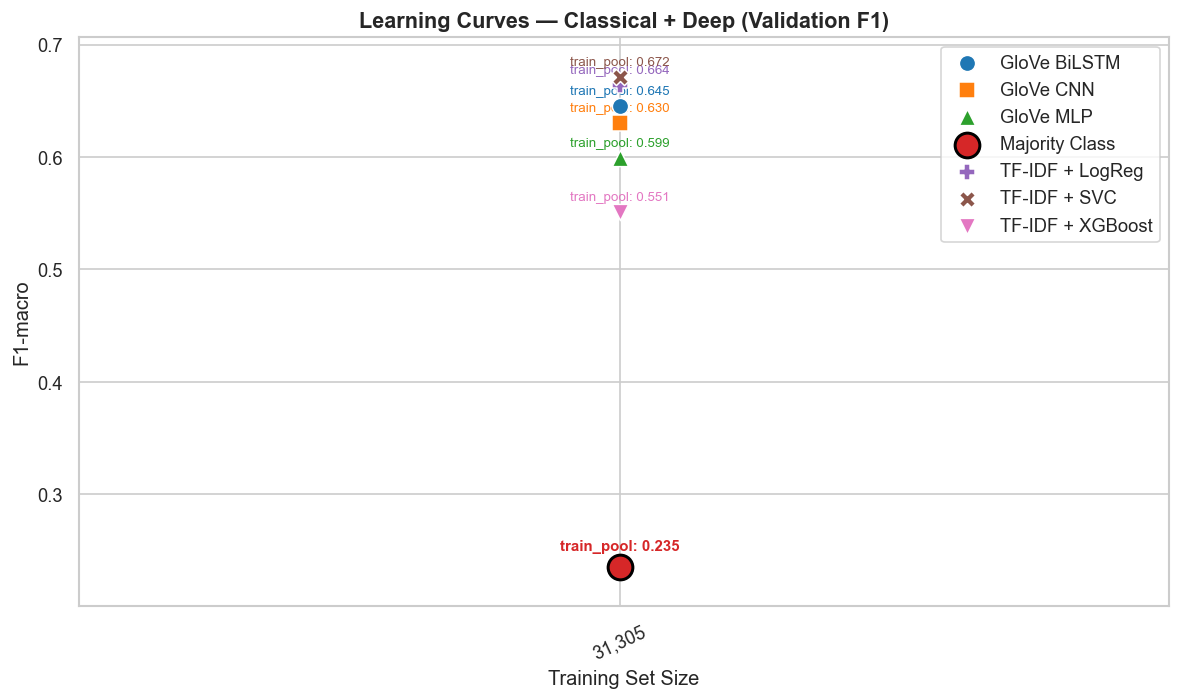

In [43]:
# -- 6.3 Summarize deep-model internal metrics and unified curves -----------
deep_curve_df, deep_val_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)

deep_test_eval_df = collect_deep_eval_from_results(
    results=RESULTS,
    splits=splits,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="test",
)

deep_internal_eval_df = (
    pd.concat([deep_val_eval_df, deep_test_eval_df], ignore_index=True)
    .sort_values(["model", "split", "train_size"])
    .reset_index(drop=True)
)
display(deep_internal_eval_df)

metrics_dir = CFG["output_paths"]["metrics"]
deep_curve_df.to_csv(metrics_dir / "deep_curve_metrics.csv", index=False)
joblib.dump(deep_curve_df, metrics_dir / "deep_curve_metrics.pkl")

deep_val_eval_df.to_csv(metrics_dir / "deep_eval_metrics_val.csv", index=False)
joblib.dump(deep_val_eval_df, metrics_dir / "deep_eval_metrics_val.pkl")

deep_test_eval_df.to_csv(metrics_dir / "deep_eval_metrics_test.csv", index=False)
joblib.dump(deep_test_eval_df, metrics_dir / "deep_eval_metrics_test.pkl")

deep_internal_eval_df.to_csv(metrics_dir / "deep_eval_metrics_internal.csv", index=False)
joblib.dump(deep_internal_eval_df, metrics_dir / "deep_eval_metrics_internal.pkl")

if deep_curve_df is not None and not deep_curve_df.empty:
    classical_part = baseline_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()

    combined_curve_df = (
        pd.concat([classical_part, deep_part], ignore_index=True)
        .drop_duplicates(subset=["model", "split_key"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )

    display(combined_curve_df)
    plot_learning_curve_from_metrics(
        combined_curve_df,
        title="Learning Curves — Classical + Deep (Validation F1)",
        save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
        force_replot=True,
    )

    combined_curve_df.to_csv(metrics_dir / "combined_curve_metrics.csv", index=False)
    joblib.dump(combined_curve_df, metrics_dir / "combined_curve_metrics.pkl")
else:
    combined_curve_df = pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])


---
<a id="section-7-transformer-fine-tuning"></a>
# SECTION 7 — Transformer Fine-Tuning

We fine-tune pretrained transformers as our strongest in-domain candidates.
We get validation and test summaries for DistilBERT and RoBERTa, and we can pick the best checkpoint for the next transfer checks.


<a id="section-7-1-preparation-architecture"></a>
## 7.1 Preparation & Architecture


**Architecture:**
- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.
- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.


In [51]:
# -- 7.1 Prepare transformer bundles and experiment registry ----------------
TRANSFORMER_RUNS = {}
BASE_TRAIN_POOL_BUNDLE = build_transformer_bundle_from_split(train_pool_key)
TRANSFORMER_SIZE_TAG = size_tag_from_split(train_pool_key)

TRANSFORMER_PLAN = pd.DataFrame([
    {
        "experiment": "DistilBERT_train_pool",
        "model_name": "distilbert-base-uncased",
        "batch_size": CFG["batch_size"],
        "epochs": CFG["epochs"],
        "lr": CFG["lr"],
    },
    {
        "experiment": "RoBERTa_train_pool",
        "model_name": "roberta-base",
        "batch_size": min(CFG["batch_size"], 8),
        "epochs": CFG["epochs"],
        "lr": 2e-5,
    },
    {
        "experiment": "DeBERTaV3_train_pool",
        "model_name": "microsoft/deberta-v3-base",
        "batch_size": 16,
        "epochs": CFG["epochs"],
        "lr": 2e-5,
    },
])
display(TRANSFORMER_PLAN)

,experiment,model_name,batch_size,epochs,lr
0,DistilBERT_train_pool,distilbert-base-uncased,8,3,0.00002
1,RoBERTa_train_pool,roberta-base,8,3,0.00002
2,DeBERTaV3_train_pool,microsoft/deberta-v3-base,16,3,0.00002


<a id="section-7-2-training"></a>
## 7.2 Training


<a id="section-7-2-1-reference-distilbert"></a>
### 7.2.1 Reference DistilBERT



### 7.2.1 Reference DistilBERT ###
DistilBERT_train_pool: best model already exists -> skip retraining (models/distilbert_complexity_train_pool_20260307_164409/best_model)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool | VAL
  Accuracy      : 0.7678
  F1 (macro)    : 0.7372
  F1 (weighted) : 0.7649

              precision    recall  f1-score   support

       A1-A2       0.81      0.68      0.74      2040
       B1-B2       0.76      0.85      0.81      3655
       C1-C2       0.71      0.62      0.66      1014

    accuracy                           0.77      6709
   macro avg       0.76      0.72      0.74      6709
weighted avg       0.77      0.77      0.76      6709


  DistilBERT_train_pool | TEST
  Accuracy      : 0.7746
  F1 (macro)    : 0.7431
  F1 (weighted) : 0.7721

              precision    recall  f1-score   support

       A1-A2       0.83      0.70      0.76      2040
       B1-B2       0.77      0.86      0.81      3655
       C1-C2       0.70      0.62      0.66      1014

    accuracy                           0.77      6709
   macro avg       0.77      0.73      0.74      6709
weighted avg       0.78      0.77      0.77      6709

Final validation F1 (ma

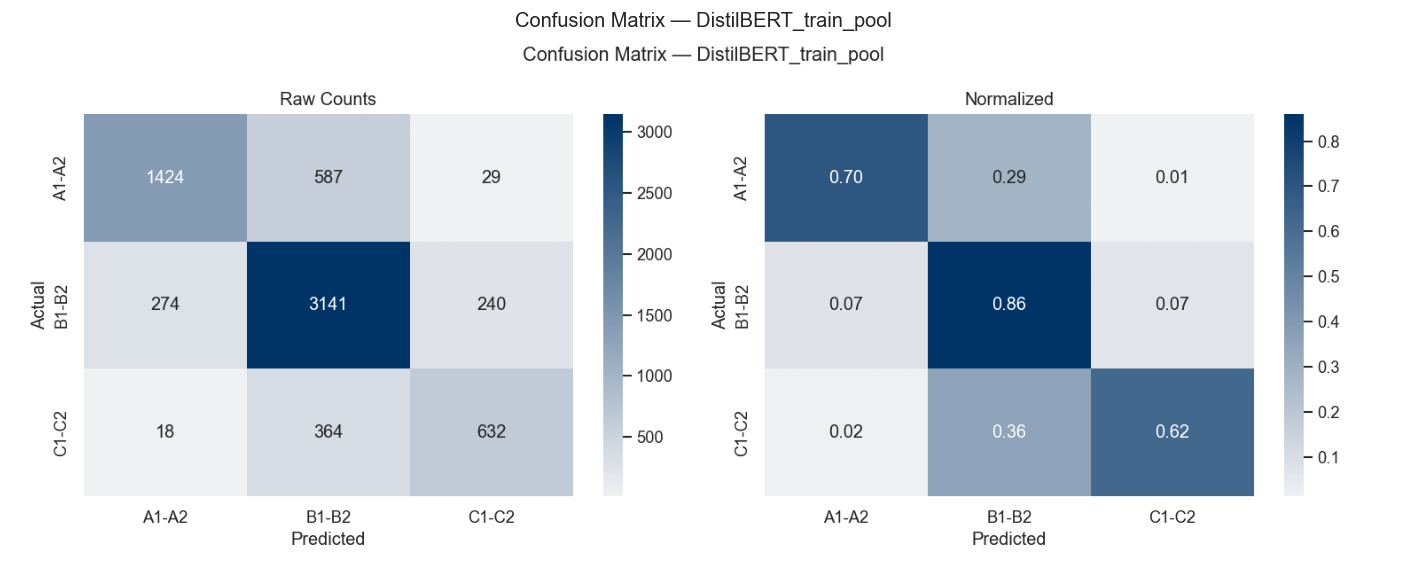

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_train_pool.png


In [52]:
# -- 7.2.1 Reference DistilBERT ---------------------------------------------
print("\n### 7.2.1 Reference DistilBERT ###")

TRANSFORMER_RUNS["DistilBERT_train_pool"] = run_transformer_experiment(
    display_name="DistilBERT_train_pool",
    family_slug="distilbert",
    size_tag=TRANSFORMER_SIZE_TAG,
    model_name="distilbert-base-uncased",
    data_bundle=BASE_TRAIN_POOL_BUNDLE,
    batch_size=CFG["batch_size"],
    epochs=CFG["epochs"],
    lr=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    early_stopping_patience=2,
    eval_mode="epoch",
)


<a id="section-7-2-2-alternative-roberta"></a>
### 7.2.2 Alternative RoBERTa



### 7.2.2 Alternative RoBERTa ###
RoBERTa_train_pool: best model already exists -> skip retraining (models/roberta_base_complexity_train_pool_20260307_162036/best_model)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


  RoBERTa_train_pool | VAL
  Accuracy      : 0.7655
  F1 (macro)    : 0.7331
  F1 (weighted) : 0.7626

              precision    recall  f1-score   support

       A1-A2       0.80      0.70      0.75      2040
       B1-B2       0.76      0.85      0.80      3655
       C1-C2       0.71      0.60      0.65      1014

    accuracy                           0.77      6709
   macro avg       0.76      0.72      0.73      6709
weighted avg       0.77      0.77      0.76      6709


  RoBERTa_train_pool | TEST
  Accuracy      : 0.7676
  F1 (macro)    : 0.7298
  F1 (weighted) : 0.7645

              precision    recall  f1-score   support

       A1-A2       0.82      0.71      0.76      2040
       B1-B2       0.76      0.85      0.81      3655
       C1-C2       0.68      0.57      0.62      1014

    accuracy                           0.77      6709
   macro avg       0.76      0.71      0.73      6709
weighted avg       0.77      0.77      0.76      6709

Final validation F1 (macro) [

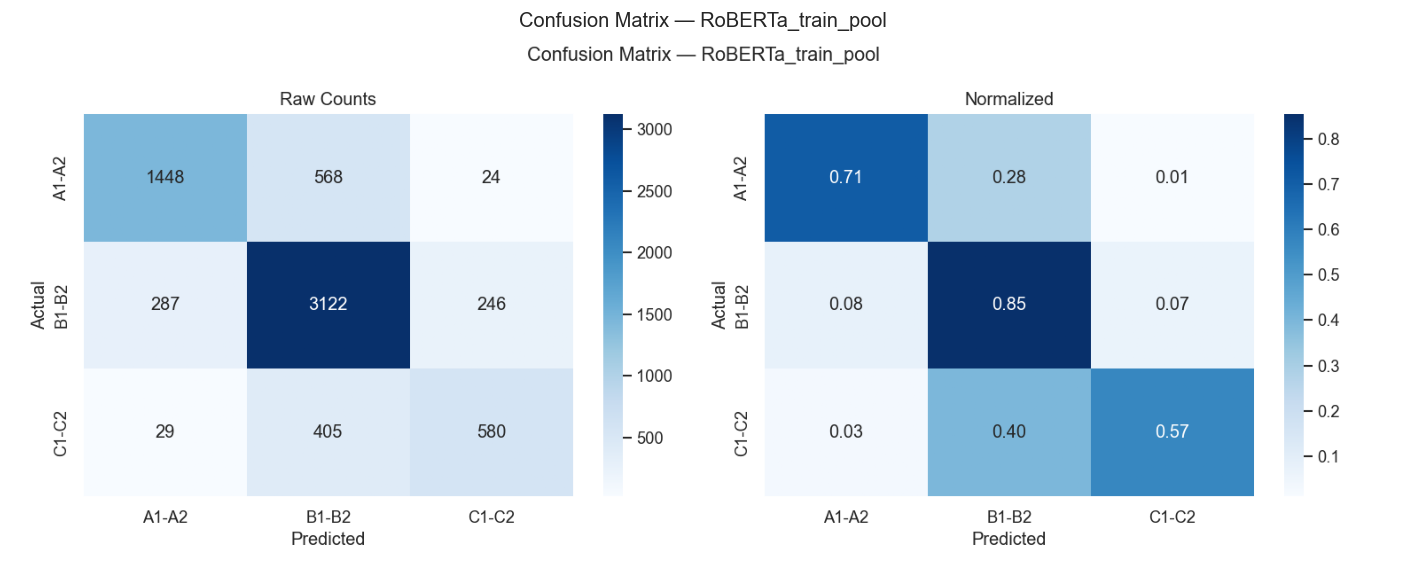

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_roberta_train_pool.png


In [53]:
# -- 7.2.2 Alternative RoBERTa ----------------------------------------------
print("\n### 7.2.2 Alternative RoBERTa ###")

TRANSFORMER_RUNS["RoBERTa_train_pool"] = run_transformer_experiment(
    display_name="RoBERTa_train_pool",
    family_slug="roberta_base",
    size_tag=TRANSFORMER_SIZE_TAG,
    model_name="roberta-base",
    data_bundle=BASE_TRAIN_POOL_BUNDLE,
    batch_size=min(CFG["batch_size"], 8),
    epochs=CFG["epochs"],
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
)


### 7.2.3 DeBERTa-v3-base

<a id="section-7-2-3-results"></a>
### 7.2.3 Results

---
<a id="section-8-cross-dataset-evaluation"></a>
# SECTION 8 — Cross-Dataset Evaluation

We take the trained classical, deep, and transformer models outside the merged UK Key Stage + ASAP 2.0 training pool.
We evaluate on the held-out external corpora only, so we can separate in-domain performance from true cross-dataset generalization across model families.



Use the prepared `external_eval_datasets` / `external_eval_bundles` registry from Section 3 to run the shared evaluation flow on each held-out complexity corpus and then aggregate the family-level summaries.


In [97]:
# -- 8.1 Cross-dataset eval for classical and deep models -------------------
DATASET_SOURCE_PATHS = {
    name: (CFG["data_dir"] / rel_path)
    for name, rel_path in globals().get("dataset_files", {}).items()
}

classical_model_names = []
if "baseline_eval_df" in globals() and not baseline_eval_df.empty:
    classical_model_names = (
        baseline_eval_df
        .query("split == 'test' and split_key == @train_pool_key")
        .sort_values(["f1_macro", "model"], ascending=[False, True])["model"]
        .drop_duplicates()
        .tolist()
    )
elif "baseline_tuning_df" in globals() and not baseline_tuning_df.empty:
    classical_model_names = (
        baseline_tuning_df.loc[
            baseline_tuning_df.get("selected", False).fillna(False), "model"
        ]
        .drop_duplicates()
        .tolist()
    )

classical_model_paths = {
    model_name: BASELINE_MODEL_REGISTRY.get(f"{model_name}|{train_pool_key}")
    for model_name in classical_model_names
}
classical_model_paths = {
    model_name: model_path
    for model_name, model_path in classical_model_paths.items()
    if model_path is not None and Path(model_path).exists()
}

if not classical_model_paths:
    raise FileNotFoundError(
        "No trained classical models found for external evaluation. "
        "Run Section 4 first so BASELINE_MODEL_REGISTRY is populated."
    )

CLASSICAL_EXTERNAL_EVAL = {}
CLASSICAL_EXTERNAL_MODELS = {
    model_name: joblib.load(Path(model_path))
    for model_name, model_path in classical_model_paths.items()
}

for dataset_name, df_external in external_eval_datasets.items():
    print()
    print(f"===== Classical external eval | {dataset_name} =====")
    CLASSICAL_EXTERNAL_EVAL[dataset_name] = {}
    data_path = DATASET_SOURCE_PATHS.get(dataset_name)

    for model_name, estimator in CLASSICAL_EXTERNAL_MODELS.items():
        output_dir = (
            CFG["output_dir"] / "cross_dataset_eval" / "classical" /
            dataset_name / slugify(model_name)
        )
        display_name = f"{model_name} [{dataset_name}]"
        model_path = classical_model_paths.get(model_name)

        CLASSICAL_EXTERNAL_EVAL[dataset_name][model_name] = evaluate_classical_model_on_df(
            display_name=display_name,
            estimator=estimator,
            df=df_external,
            label_encoder=le,
            output_dir=output_dir,
            data_paths=data_path,
            model_path=model_path,
            cfg=CFG,
            plot_confusion=False,
        )

DEEP_EXTERNAL_EVAL = {}
DEEP_EXTERNAL_MODELS = {}
for model_label, model_spec in DEEP_MODEL_SPECS.items():
    if model_label in DEEP_RUNS and DEEP_RUNS[model_label].get("model") is not None:
        DEEP_EXTERNAL_MODELS[model_label] = {
            "model": DEEP_RUNS[model_label]["model"],
            "checkpoint_path": DEEP_RUNS[model_label].get("best_checkpoint"),
        }
    else:
        model_obj, ckpt_path, _ = load_best_torch_model(
            model_builder=model_spec["builder"],
            family_slug=model_spec["family_slug"],
            split_key=train_pool_key,
            cfg=CFG,
        )
        DEEP_EXTERNAL_MODELS[model_label] = {
            "model": model_obj,
            "checkpoint_path": str(ckpt_path),
        }

for dataset_name, df_external in external_eval_datasets.items():
    print()
    print(f"===== Deep external eval | {dataset_name} =====")
    DEEP_EXTERNAL_EVAL[dataset_name] = {}
    data_path = DATASET_SOURCE_PATHS.get(dataset_name)
    eval_bundle = build_sequence_eval_bundle_from_df(
        df_external,
        dataset_name=dataset_name,
        vocab=vocab,
        cfg=CFG,
        drop_duplicates=False,
    )

    for model_label, model_payload in DEEP_EXTERNAL_MODELS.items():
        output_dir = (
            CFG["output_dir"] / "cross_dataset_eval" / "deep" /
            dataset_name / slugify(model_label)
        )
        display_name = f"{model_label} [{dataset_name}]"

        DEEP_EXTERNAL_EVAL[dataset_name][model_label] = evaluate_torch_model_on_bundle(
            display_name=display_name,
            model=model_payload.get("model"),
            eval_bundle=eval_bundle,
            label_encoder=le,
            output_dir=output_dir,
            data_paths=data_path,
            checkpoint_path=model_payload.get("checkpoint_path"),
            cfg=CFG,
            plot_confusion=False,
        )



===== Classical external eval | one_stop =====
TF-IDF + SVC [one_stop]: loaded cached metrics -> outputs/cross_dataset_eval/classical/one_stop/tf_idf_svc/metrics_latest.json
TF-IDF + LogReg [one_stop]: loaded cached metrics -> outputs/cross_dataset_eval/classical/one_stop/tf_idf_logreg/metrics_latest.json
TF-IDF + XGBoost [one_stop]: loaded cached metrics -> outputs/cross_dataset_eval/classical/one_stop/tf_idf_xgboost/metrics_latest.json
Majority Class [one_stop]: loaded cached metrics -> outputs/cross_dataset_eval/classical/one_stop/majority_class/metrics_latest.json

===== Classical external eval | commonlit =====
TF-IDF + SVC [commonlit]: loaded cached metrics -> outputs/cross_dataset_eval/classical/commonlit/tf_idf_svc/metrics_latest.json
TF-IDF + LogReg [commonlit]: loaded cached metrics -> outputs/cross_dataset_eval/classical/commonlit/tf_idf_logreg/metrics_latest.json
TF-IDF + XGBoost [commonlit]: loaded cached metrics -> outputs/cross_dataset_eval/classical/commonlit/tf_idf_xg

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool [one_stop] | EVAL
  Accuracy      : 0.3708
  F1 (macro)    : 0.2742
  F1 (weighted) : 0.2746

              precision    recall  f1-score   support

       A1-A2       0.43      0.09      0.15       176
       B1-B2       0.35      0.92      0.51       170
       C1-C2       0.79      0.09      0.17       161

    accuracy                           0.37       507
   macro avg       0.52      0.37      0.27       507
weighted avg       0.52      0.37      0.27       507

Final evaluation F1 (macro) [DistilBERT_train_pool [one_stop]]: 0.2742
DistilBERT_train_pool [one_stop] | EVAL metrics: {'accuracy': 0.3708086785009862, 'f1_macro': 0.27417915976805546, 'f1_weighted': 0.27462086771678995}


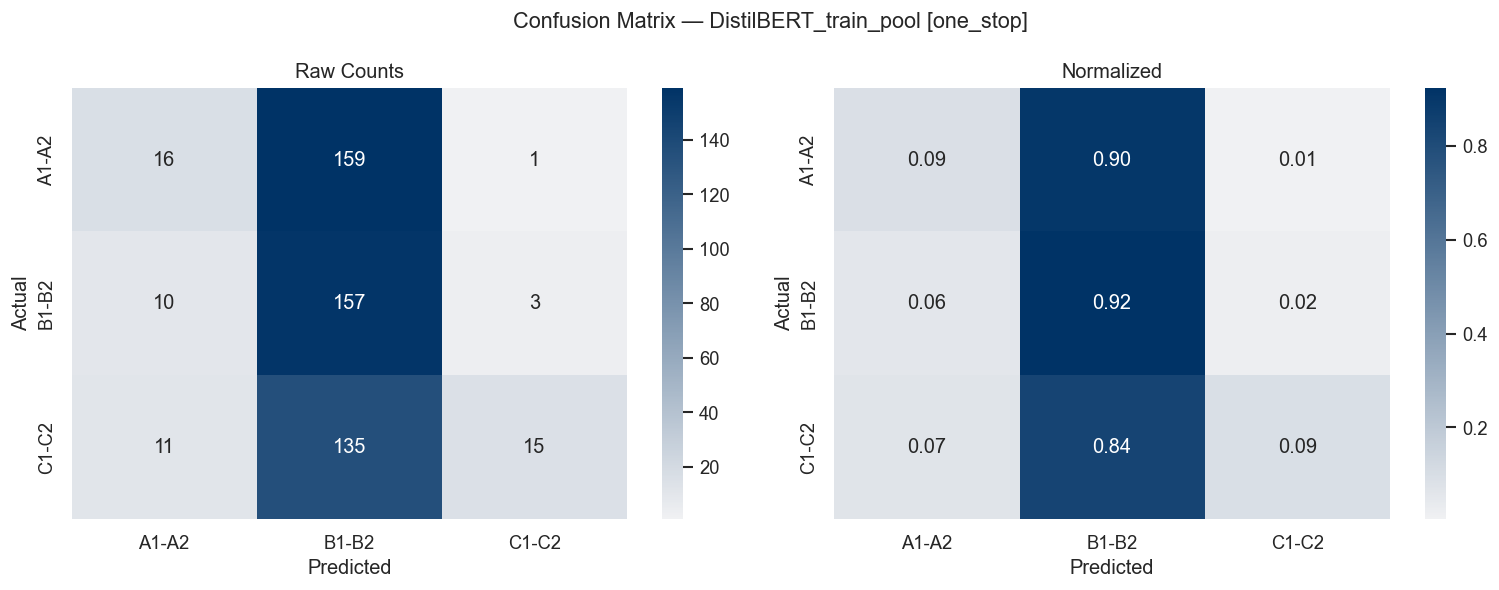

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool [commonlit] | EVAL
  Accuracy      : 0.3731
  F1 (macro)    : 0.3408
  F1 (weighted) : 0.3665

              precision    recall  f1-score   support

       A1-A2       0.21      0.47      0.29       904
       B1-B2       0.47      0.49      0.48      2208
       C1-C2       0.62      0.16      0.25      1611

    accuracy                           0.37      4723
   macro avg       0.43      0.37      0.34      4723
weighted avg       0.47      0.37      0.37      4723

Final evaluation F1 (macro) [DistilBERT_train_pool [commonlit]]: 0.3408
DistilBERT_train_pool [commonlit] | EVAL metrics: {'accuracy': 0.3730679652763074, 'f1_macro': 0.34084437291880687, 'f1_weighted': 0.3664941958780719}


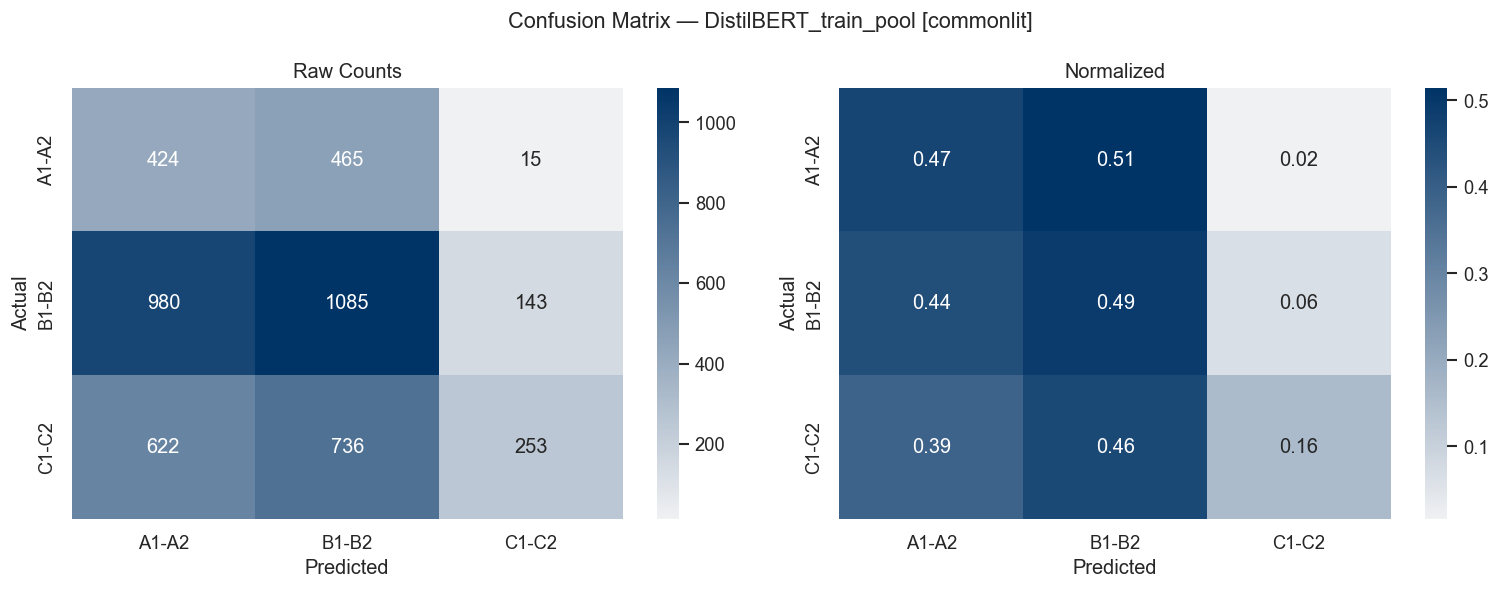

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool [cerf] | EVAL
  Accuracy      : 0.4796
  F1 (macro)    : 0.4515
  F1 (weighted) : 0.4603

              precision    recall  f1-score   support

       A1-A2       0.61      0.49      0.54       559
       B1-B2       0.38      0.72      0.50       491
       C1-C2       0.78      0.19      0.31       443

    accuracy                           0.48      1493
   macro avg       0.59      0.47      0.45      1493
weighted avg       0.59      0.48      0.46      1493

Final evaluation F1 (macro) [DistilBERT_train_pool [cerf]]: 0.4515
DistilBERT_train_pool [cerf] | EVAL metrics: {'accuracy': 0.4795713328868051, 'f1_macro': 0.4515103619410013, 'f1_weighted': 0.4602645616354244}


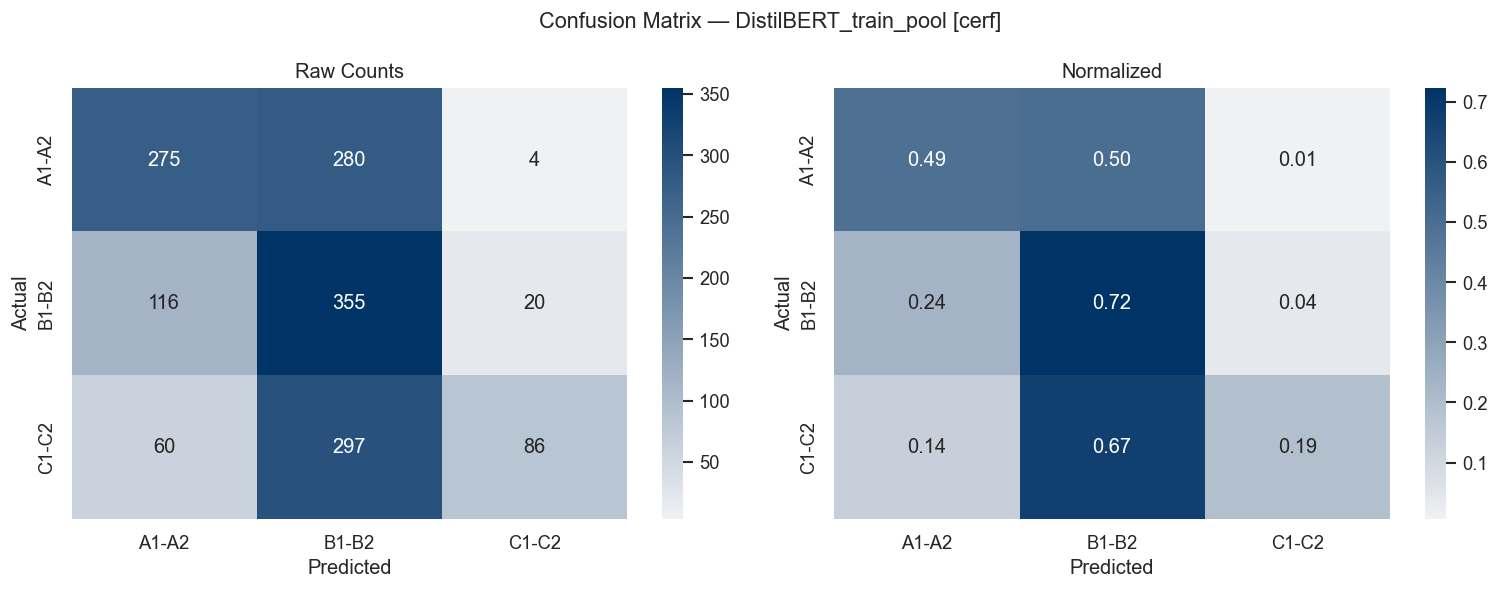

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool [cambridge] | EVAL
  Accuracy      : 0.4854
  F1 (macro)    : 0.4437
  F1 (weighted) : 0.4532

              precision    recall  f1-score   support

       A1-A2       0.41      0.48      0.44        61
       B1-B2       0.47      0.73      0.57       116
       C1-C2       0.86      0.20      0.32        97

    accuracy                           0.49       274
   macro avg       0.58      0.47      0.44       274
weighted avg       0.60      0.49      0.45       274

Final evaluation F1 (macro) [DistilBERT_train_pool [cambridge]]: 0.4437
DistilBERT_train_pool [cambridge] | EVAL metrics: {'accuracy': 0.4854014598540146, 'f1_macro': 0.4437040809589829, 'f1_weighted': 0.4531938927602302}


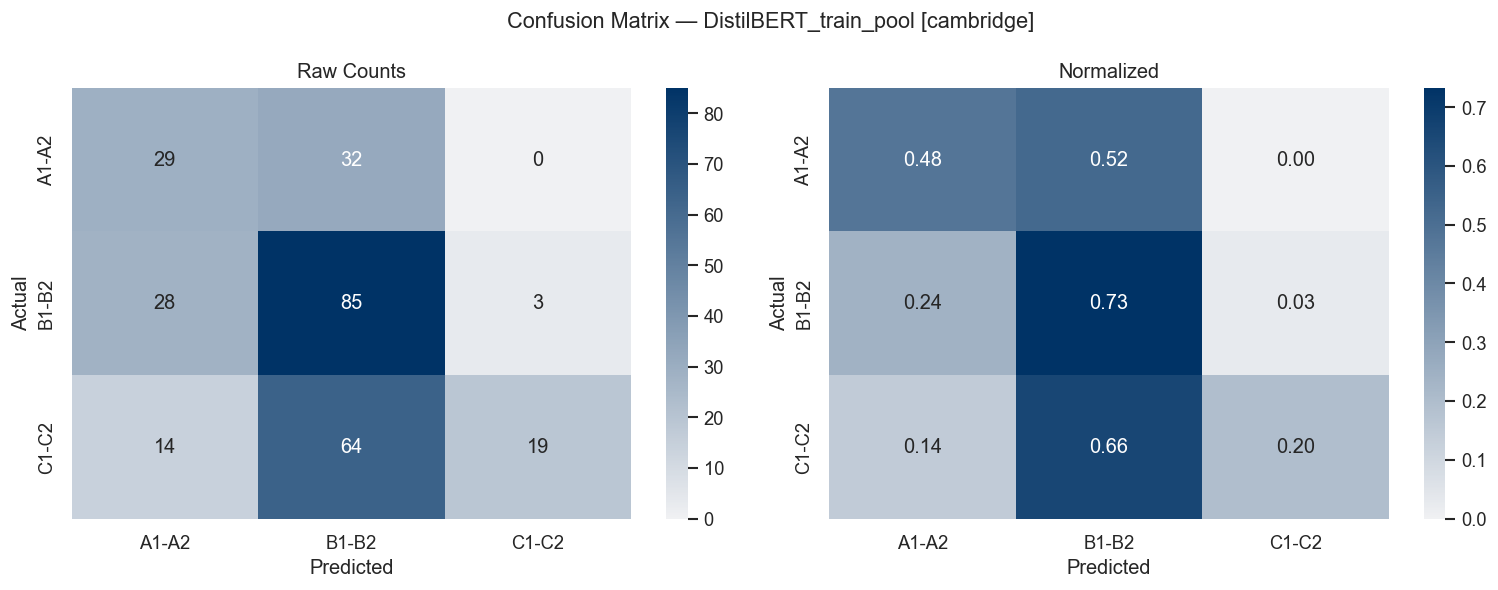

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


  DistilBERT_train_pool [asap_aes] | EVAL
  Accuracy      : 0.3606
  F1 (macro)    : 0.2664
  F1 (weighted) : 0.3092

              precision    recall  f1-score   support

       A1-A2       0.16      0.36      0.22      2527
       B1-B2       0.51      0.62      0.56      6037
       C1-C2       0.43      0.01      0.02      4408

    accuracy                           0.36     12972
   macro avg       0.37      0.33      0.27     12972
weighted avg       0.41      0.36      0.31     12972

Final evaluation F1 (macro) [DistilBERT_train_pool [asap_aes]]: 0.2664
DistilBERT_train_pool [asap_aes] | EVAL metrics: {'accuracy': 0.360622880049337, 'f1_macro': 0.26638028306507877, 'f1_weighted': 0.3091536049227754}


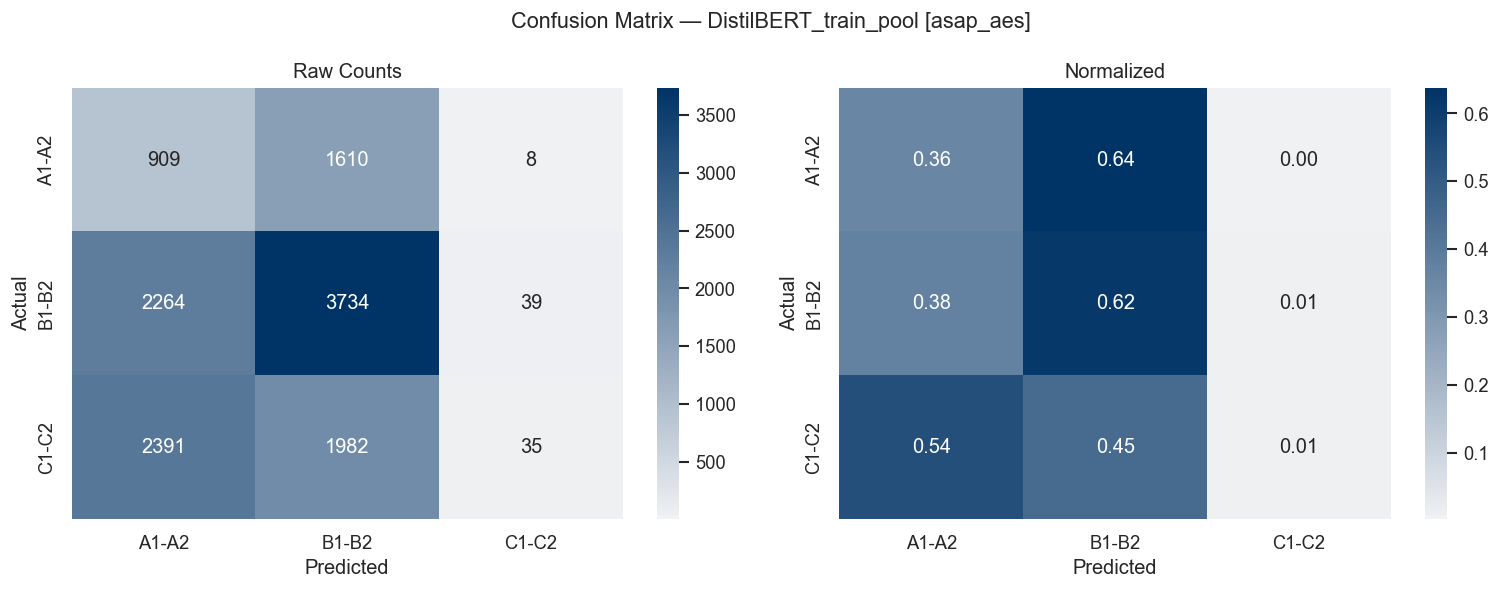

Cross-dataset transformer artefacts saved under: outputs/cross_dataset_eval/transformer


In [98]:
# -- 8.2 Cross-dataset eval for the final transformer -----------------------
CROSS_DATASET_EVAL = {}

cross_eval_model_name, cross_eval_best_dir = resolve_final_transformer_selection(CFG)
if not cross_eval_best_dir.exists():
    raise FileNotFoundError(
        f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
    )

for dataset_name, bundle in external_eval_bundles.items():
    cross_eval_dir = CFG["output_dir"] / "cross_dataset_eval" / "transformer" / dataset_name
    cross_eval_dir.mkdir(parents=True, exist_ok=True)
    data_path = DATASET_SOURCE_PATHS.get(dataset_name)
    display_name = f"{cross_eval_model_name} [{dataset_name}]"

    CROSS_DATASET_EVAL[dataset_name] = run_cross_dataset_transformer_eval(
        display_name=display_name,
        data_bundle=bundle,
        output_dir=cross_eval_dir,
        best_model_dir=cross_eval_best_dir,
        data_paths=data_path,
    )

print(f"Cross-dataset transformer artefacts saved under: {CFG['output_dir'] / 'cross_dataset_eval' / 'transformer'}")


In [99]:
# -- 8.3 Aggregate cross-dataset metrics across model families --------------
cross_dataset_rows = []

for dataset_name, payloads in sorted(CLASSICAL_EXTERNAL_EVAL.items()):
    for model_name, payload in sorted(payloads.items()):
        eval_metrics = payload.get("metrics", {}).get("eval", {})
        cross_dataset_rows.append({
            "family": "classical",
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": float(eval_metrics.get("accuracy", np.nan)),
            "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
        })

for dataset_name, payloads in sorted(DEEP_EXTERNAL_EVAL.items()):
    for model_name, payload in sorted(payloads.items()):
        eval_metrics = payload.get("metrics", {}).get("eval", {})
        cross_dataset_rows.append({
            "family": "deep",
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": float(eval_metrics.get("accuracy", np.nan)),
            "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
        })

for dataset_name, payload in sorted(CROSS_DATASET_EVAL.items()):
    eval_metrics = payload.get("metrics", {}).get("eval", {})
    cross_dataset_rows.append({
        "family": "transformer",
        "dataset": dataset_name,
        "model": payload.get("model", FINAL_TRANSFORMER_NAME),
        "accuracy": float(eval_metrics.get("accuracy", np.nan)),
        "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
    })

if cross_dataset_rows:
    cross_dataset_summary_df = (
        pd.DataFrame(cross_dataset_rows)
        .sort_values(["family", "dataset", "f1_macro"], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    baseline_external_eval_df = cross_dataset_summary_df.query("family == 'classical'").reset_index(drop=True)
    deep_external_eval_df = cross_dataset_summary_df.query("family == 'deep'").reset_index(drop=True)
    transformer_external_summary_df = cross_dataset_summary_df.query("family == 'transformer'").reset_index(drop=True)

    cross_dataset_family_summary_df = (
        cross_dataset_summary_df
        .groupby("family", as_index=False)[["accuracy", "f1_macro", "f1_weighted"]]
        .mean()
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )

    display(cross_dataset_summary_df.round(4))
    display(cross_dataset_family_summary_df.round(4))

    cross_dataset_root = CFG["output_dir"] / "cross_dataset_eval"
    cross_dataset_root.mkdir(parents=True, exist_ok=True)
    cross_dataset_summary_df.to_csv(cross_dataset_root / "summary_latest.csv", index=False)
    cross_dataset_family_summary_df.to_csv(cross_dataset_root / "family_summary_latest.csv", index=False)
    print(f"Cross-dataset summary saved to: {cross_dataset_root / 'summary_latest.csv'}")
else:
    cross_dataset_summary_df = pd.DataFrame(
        columns=["family", "dataset", "model", "accuracy", "f1_macro", "f1_weighted"]
    )
    baseline_external_eval_df = cross_dataset_summary_df.copy()
    deep_external_eval_df = cross_dataset_summary_df.copy()
    transformer_external_summary_df = cross_dataset_summary_df.copy()
    cross_dataset_family_summary_df = pd.DataFrame(
        columns=["family", "accuracy", "f1_macro", "f1_weighted"]
    )
    print("No cross-dataset evaluations were collected.")


,family,dataset,model,accuracy,f1_macro,f1_weighted
0,classical,asap_aes,TF-IDF + LogReg,0.5168,0.4867,0.5132
1,classical,asap_aes,TF-IDF + SVC,0.4990,0.4516,0.4830
2,classical,asap_aes,TF-IDF + XGBoost,0.3950,0.2348,0.2892
3,classical,asap_aes,Majority Class,0.4654,0.2117,0.2956
4,classical,cambridge,TF-IDF + SVC,0.5620,0.5142,0.5423
5,classical,cambridge,TF-IDF + LogReg,0.5146,0.4777,0.4884
6,classical,cambridge,TF-IDF + XGBoost,0.5401,0.4629,0.4972
7,classical,cambridge,Majority Class,0.4234,0.1983,0.2518
8,classical,cerf,TF-IDF + SVC,0.5244,0.5244,0.5192
9,classical,cerf,TF-IDF + LogReg,0.5171,0.5046,0.5008


,family,accuracy,f1_macro,f1_weighted
0,deep,0.4585,0.3971,0.4140
1,transformer,0.4139,0.3553,0.3727
2,classical,0.4458,0.3359,0.3630


Cross-dataset summary saved to: outputs/cross_dataset_eval/summary_latest.csv


---
<a id="section-9-model-comparison-results-table"></a>
# SECTION 9 — Model Comparison & Results Table

We collect everything in one place for a final comparison.
We get the consolidated table, comparison plots, and a small error sample, and we can read the ranking at a glance before writing the full report.


In [100]:
# -- 9.1 print_results_table() ----------------------------------------------
print_results_table()



Model                                              accuracy      f1_macro   f1_weighted
TF-IDF + SVC [one_stop] | eval                       0.3688        0.2974        0.2902
TF-IDF + LogReg [one_stop] | eval                    0.3452        0.2502        0.2429
TF-IDF + XGBoost [one_stop] | eval                   0.3688        0.2494        0.2466
Majority Class [one_stop] | eval                     0.3353        0.1674        0.1684
TF-IDF + SVC [commonlit] | eval                      0.4796        0.3954        0.4513
TF-IDF + LogReg [commonlit] | eval                   0.4645        0.3885        0.4336
TF-IDF + XGBoost [commonlit] | eval                  0.4554        0.2662        0.3313
Majority Class [commonlit] | eval                    0.4675        0.2124        0.2979
TF-IDF + SVC [cerf] | eval                           0.5244        0.5244        0.5192
TF-IDF + LogReg [cerf] | eval                        0.5171        0.5046        0.5008
TF-IDF + XGBoost [cerf] | eval 

In [101]:
# -- 9.2 Build and persist the consolidated results table -------------------
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .reset_index()
)
df_results[["model_name", "metric_split"]] = df_results["Model | Split"].str.rsplit(" | ", n=1, expand=True)
df_results = df_results.sort_values(["metric_split", "f1_macro"], ascending=[True, False]).reset_index(drop=True)
display(df_results.round(4))

df_results.to_csv(CFG["output_paths"]["metrics"] / f"results_{CFG['task']}.csv", index=False)
print("Results saved.")

internal_test_leaderboard_df = (
    df_results[
        (df_results["metric_split"] == "test") &
        (~df_results["model_name"].str.startswith("LC |"))
    ]
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
display(internal_test_leaderboard_df.head(15).round(4))


,Model | Split,accuracy,f1_macro,f1_weighted,model_name,metric_split
0,GloVe BiLSTM [cerf] | eval,0.5934,0.6026,0.6005,GloVe BiLSTM [cerf],eval
1,GloVe BiLSTM [cambridge] | eval,0.5438,0.5316,0.5240,GloVe BiLSTM [cambridge],eval
2,TF-IDF + SVC [cerf] | eval,0.5244,0.5244,0.5192,TF-IDF + SVC [cerf],eval
3,TF-IDF + SVC [cambridge] | eval,0.5620,0.5142,0.5423,TF-IDF + SVC [cambridge],eval
4,TF-IDF + LogReg [cerf] | eval,0.5171,0.5046,0.5008,TF-IDF + LogReg [cerf],eval
5,TF-IDF + LogReg [asap_aes] | eval,0.5168,0.4867,0.5132,TF-IDF + LogReg [asap_aes],eval
6,TF-IDF + LogReg [cambridge] | eval,0.5146,0.4777,0.4884,TF-IDF + LogReg [cambridge],eval
7,GloVe CNN [cerf] | eval,0.4756,0.4690,0.4714,GloVe CNN [cerf],eval
8,TF-IDF + XGBoost [cambridge] | eval,0.5401,0.4629,0.4972,TF-IDF + XGBoost [cambridge],eval
9,TF-IDF + SVC [asap_aes] | eval,0.4990,0.4516,0.4830,TF-IDF + SVC [asap_aes],eval


Results saved.


,Model | Split,accuracy,f1_macro,f1_weighted,model_name,metric_split


In [102]:
# -- 9.3 Plot model comparison charts ---------------------------------------
plot_model_comparison(RESULTS, metric="f1_macro", split="val")
plot_model_comparison(RESULTS, metric="f1_macro", split="test")
plot_model_comparison(RESULTS, metric="accuracy", split="test")


No results for split='val', metric='f1_macro'.
No results for split='test', metric='f1_macro'.
No results for split='test', metric='accuracy'.


In [103]:
# -- 9.4 Error analysis for the final transformer ---------------------------
print(f"=== Error Analysis — {globals().get('FINAL_TRANSFORMER_NAME', 'Transformer')} ===")
error_df = error_analysis(
    globals().get("trf_df_test", df_test),
    globals().get("trf_y_test", y_test),
    globals().get("trf_test_preds", np.asarray([])),
    le,
    n=10,
)
display(error_df)


=== Error Analysis — DistilBERT_train_pool ===


ValueError: y_true and y_pred length mismatch: 6709 vs 0

---
<a id="section-10-saving-logging-final-report"></a>
# SECTION 10 — Saving, Logging & Final Report

We save the main artefacts and sanity-check the best model on short real sentences.
We get reusable outputs and quick manual predictions, and we can confirm that obvious cases look sensible while borderline ones stay trickier.


<a id="section-10-1-save-artefacts"></a>
## 10.1 Save Artefacts


In [ ]:
# -- 10.1 Save artefacts ----------------------------------------------------
save_artefacts()


<a id="section-10-2-manual-inference-sanity-check"></a>
## 10.2 Manual Inference Sanity Check


In [104]:
# -- 10.2.1 Load best transformer checkpoint for manual checks --------------
_, resolved_model_path = resolve_final_transformer_selection(CFG)
MODEL_PATH = str(resolved_model_path)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device(CFG["device"])
model.to(device)
model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [105]:
# -- 10.2.2 Example texts for manual complexity checks ----------------------
example_texts = [
    "The boy has a small dog. The dog is brown and friendly.",
    "My sister goes to school by bus and comes home in the afternoon.",
    "The museum opened a new room where visitors can learn about life in ancient cities.",
    "Although the weather forecast predicted heavy rain, the match continued because the pitch remained playable.",
    "Researchers compared the two groups carefully in order to determine whether the intervention had any measurable effect.",
    "Notwithstanding the apparent simplicity of the proposal, its implementation would require a sequence of interdependent regulatory revisions.",
    "The committee acknowledged that, in the absence of reliable longitudinal evidence, any definitive conclusion would remain provisional.",
    "By foregrounding the tension between economic efficiency and social equity, the report complicates any straightforward interpretation of the policy debate.",
]

for i, text in enumerate(example_texts, start=1):
    label, conf = predict_one(text)
    print(f"{i}. Text: {text}")
    print(f"   Prediction: {label} | Confidence: {conf:.4f}")
    print("-" * 100)


1. Text: The boy has a small dog. The dog is brown and friendly.
   Prediction: B1-B2 | Confidence: 0.8956
----------------------------------------------------------------------------------------------------
2. Text: My sister goes to school by bus and comes home in the afternoon.
   Prediction: B1-B2 | Confidence: 0.6107
----------------------------------------------------------------------------------------------------
3. Text: The museum opened a new room where visitors can learn about life in ancient cities.
   Prediction: B1-B2 | Confidence: 0.8169
----------------------------------------------------------------------------------------------------
4. Text: Although the weather forecast predicted heavy rain, the match continued because the pitch remained playable.
   Prediction: B1-B2 | Confidence: 0.4634
----------------------------------------------------------------------------------------------------
5. Text: Researchers compared the two groups carefully in order to determine w

<a id="section-10-3-final-report"></a>
## 10.3 Final Report

We built the complexity pipeline around one shared in-domain pool: UK Key Stage plus ASAP 2.0 are merged, stratified into train, validation, and internal test subsets, and reused consistently across model families.
All remaining corpora are kept out of training and prepared as external evaluation sets, so later sections can measure both internal performance and cross-dataset generalization with the same label mapping and preprocessing contract.
This keeps the notebook aligned with the age project’s workflow while adapting the split policy, labels, sequence length, and evaluation boundaries to the readability-complexity task.


In [106]:
# -- 10.3 Final report summary ----------------------------------------------
family_internal_rows = []

baseline_test_df = baseline_eval_df.query("split == 'test'").sort_values("f1_macro", ascending=False)
if not baseline_test_df.empty:
    best_row = baseline_test_df.iloc[0]
    family_internal_rows.append({
        "family": "classical",
        "model": best_row["model"],
        "test_f1_macro": float(best_row["f1_macro"]),
        "test_accuracy": float(best_row["accuracy"]),
    })

deep_test_df = deep_test_eval_df.sort_values("f1_macro", ascending=False)
if not deep_test_df.empty:
    best_row = deep_test_df.iloc[0]
    family_internal_rows.append({
        "family": "deep",
        "model": best_row["model"],
        "test_f1_macro": float(best_row["f1_macro"]),
        "test_accuracy": float(best_row["accuracy"]),
    })

if "transformer_summary_df" in globals() and not transformer_summary_df.empty:
    best_row = transformer_summary_df.sort_values("test_f1_macro", ascending=False).iloc[0]
    family_internal_rows.append({
        "family": "transformer",
        "model": best_row["experiment"],
        "test_f1_macro": float(best_row["test_f1_macro"]),
        "test_accuracy": float(
            TRANSFORMER_RUNS[best_row["experiment"]]["test_metrics"].get("accuracy", np.nan)
        ),
    })

family_internal_summary_df = pd.DataFrame(family_internal_rows)
if not family_internal_summary_df.empty:
    display(family_internal_summary_df.sort_values("test_f1_macro", ascending=False).round(4))

model_external_mean_df = pd.DataFrame()
if "cross_dataset_summary_df" in globals() and not cross_dataset_summary_df.empty:
    model_external_mean_df = (
        cross_dataset_summary_df
        .groupby(["family", "model"], as_index=False)[["accuracy", "f1_macro", "f1_weighted"]]
        .mean()
        .sort_values("f1_macro", ascending=False)
        .reset_index(drop=True)
    )
    display(model_external_mean_df.round(4))
    display(cross_dataset_family_summary_df.round(4))

internal_candidates = (
    df_results[
        (df_results["metric_split"] == "test") &
        (~df_results["model_name"].str.startswith("LC |"))
    ]
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)
best_internal_row = internal_candidates.iloc[0] if not internal_candidates.empty else None
best_external_row = model_external_mean_df.iloc[0] if not model_external_mean_df.empty else None

print(f"In-domain train pool: {train_pool_key} = {' + '.join(train_pool_sources)}")
print(f"Held-out external corpora: {', '.join(sorted(external_eval_datasets))}")
if best_internal_row is not None:
    print(
        f"Best internal-test model: {best_internal_row['model_name']} | "
        f"F1-macro={best_internal_row['f1_macro']:.4f} | "
        f"accuracy={best_internal_row.get('accuracy', np.nan):.4f}"
    )
if best_external_row is not None:
    print(
        f"Best mean external model: {best_external_row['model']} ({best_external_row['family']}) | "
        f"F1-macro={best_external_row['f1_macro']:.4f} | "
        f"accuracy={best_external_row['accuracy']:.4f}"
    )


,family,model,test_f1_macro,test_accuracy
0,classical,TF-IDF + SVC,0.6687,0.7003
1,deep,GloVe BiLSTM,0.6552,0.6927


,family,model,accuracy,f1_macro,f1_weighted
0,transformer,DistilBERT_train_pool [cerf],0.4796,0.4515,0.4603
1,transformer,DistilBERT_train_pool [cambridge],0.4854,0.4437,0.4532
2,classical,TF-IDF + SVC,0.4868,0.4366,0.4572
3,classical,TF-IDF + LogReg,0.4716,0.4215,0.4358
4,deep,GloVe BiLSTM,0.4649,0.4179,0.4281
5,deep,GloVe CNN,0.4630,0.3989,0.4181
6,deep,GloVe MLP,0.4477,0.3744,0.3957
7,transformer,DistilBERT_train_pool [commonlit],0.3731,0.3408,0.3665
8,classical,TF-IDF + XGBoost,0.4209,0.2943,0.3237
9,transformer,DistilBERT_train_pool [one_stop],0.3708,0.2742,0.2746


,family,accuracy,f1_macro,f1_weighted
0,deep,0.4585,0.3971,0.4140
1,transformer,0.4139,0.3553,0.3727
2,classical,0.4458,0.3359,0.3630


In-domain train pool: train_pool = uk_key_stage + asap2
Held-out external corpora: asap_aes, cambridge, cerf, commonlit, one_stop
Best mean external model: DistilBERT_train_pool [cerf] (transformer) | F1-macro=0.4515 | accuracy=0.4796
